In [1]:
# Import library
import warnings
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from typing import Dict, Tuple

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Data Loading and Processing

We drop the duplicated variable including month, day_of_week_cat, park_cat, visitors_capped, log1p_visitors. 

In [2]:
# Read dataset
dat = pd.read_csv("demand_data.csv")

In [3]:
dat.columns

Index(['visit_date', 'park', 'visitors', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week',
       'day_of_year', 'sin_annual', 'cos_annual', 'month', 'has_nof_lagoon', 'month_of_year_cat', 'day_of_week_cat', 'park_cat', 'visitors_capped', 'log1p_visitors'],
      dtype='str')

In [4]:
# Let's drop the duplicated variable
# This includes month, day_of_week_cat, park_cat, visitors_capped, log1p_visitors

# List of columns to remove
cols_to_drop = [
    "month", 
    "day_of_week_cat", 
    "park_cat", 
    "visitors_capped", 
    "log1p_visitors",
    "month_of_year_cat"
]

# Drop columns only if they currently exist in the dataframe
dat = dat.drop(columns=[c for c in cols_to_drop if c in dat.columns])

# Verify the changes
print(f"Remaining columns: {dat.columns.tolist()}")
dat.head()

Remaining columns: ['visit_date', 'park', 'visitors', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week', 'day_of_year', 'sin_annual', 'cos_annual', 'has_nof_lagoon']


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0


# Metrics Function

**Why we should focus on WMAPE (Weighted Mean Absolute Percentage Error) compared to R^2?**

For the purpose of operational forecasting, we prioritize Weighted Mean Absolute Percentage Error (WMAPE) over $R^2$ as our primary performance metric because it directly aligns with business decision-making and resource allocation. 

While $R^2$ is a statistical measure of variance that is heavily penalized by the extreme, non-linear attendance spikes typical of holiday seasons, WMAPE provides a clear, interpretable percentage representing our average forecast error. 

Because WMAPE weights errors relative to the actual visitor volume, it allows us to quantify our operational margin of error in practical terms—providing management with a reliable answer to "how inaccurate is our staffing plan?" rather than an abstract statistical coefficient that can be disproportionately skewed by the very events we are trying to predict.

WMAPE calculates the total error relative to the total volume. This ensures that your accuracy on high-traffic days (like a holiday) matters more to the metric than your accuracy on a slow Tuesday.

Eg, WMAPE = 10%, it means on average every day there is a 10% error rate in prediction error for the visitors count, hence we should prepare a buffer of 10% in case there is a sudden rise or drop in the number of visitors. In addition, we specify in the previous working file that our goal is to achieve only 10% of WMAPE. 

In [5]:
# Define the get metrics function
# Note the benchmark r2 is 0.1424

def get_metrics(y_true, y_pred, model_fit=None):
    """Evaluation suite that handles both OLS and tree-based models."""
    denom = np.sum(np.abs(y_true))
    wmape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan
    
    # Calculate Adj R2 ONLY if a valid model_fit object with the attribute exists
    adj_r2 = np.nan
    if model_fit is not None and hasattr(model_fit, 'rsquared_adj'):
        adj_r2 = model_fit.rsquared_adj
        
    return {
        "wmape": wmape,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "bias": np.mean(y_pred - y_true),
        "adj_r2": adj_r2
    }

# Model Fitting

In [6]:
# Training random forest for two separate parks

# 2. Setup Feature Groups
cat_features_no_park = ['day_of_week', 'month_of_year']
numeric_features = [
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon'
]

**Feature Documentation: days_to_holiday**

1. What is this variable?
- The days_to_holiday variable is a temporal proximity feature (often called a "countdown" feature). For any given date in the dataset, it calculates the number of days remaining until the next upcoming public holiday.
- If today is a holiday, the value is 0.
- If the next holiday is 1 day away (e.g., the day before a public holiday), the value is 1.
- If the next holiday is one week away, the value is 7.

2. Why are we adding this?
Standard holiday flags (0 or 1) treat holidays as "point events"—the model only learns to adjust its prediction on the exact day the holiday occurs. However, real-world human behavior is not a "step function"; it is a gradual process. Adding this variable allows the model to capture the "Anticipation Effect":

- Behavioral Buildup: Theme park attendance often begins to climb in the days leading up to a long weekend or festive season as families finalize travel plans or take advantage of pre-holiday promotions.
- Marketing Impact: Theme parks frequently run "pre-holiday" sales or events that drive traffic before the actual holiday dates.
- Modeling "The Slope": By providing this countdown, we are essentially turning a "cliff" (the sudden spike of a holiday) into a "ramp." This gives the algorithm a gradient to follow, making it easier for models like XGBoost to learn the buildup of the attendance spike rather than just reacting to the peak.

3. How to interpret it?
The feature should be interpreted as a distance-to-event metric:

Decreasing values indicate an approaching spike: As the value drops from 7 down to 1, the model learns that we are entering a high-traffic window. This allows the model to "warm up" its predictions, correctly forecasting higher visitor numbers even before the holiday actually begins.

- The value of 0 is a specific state: A value of 0 indicates the peak event day, which the model correlates with maximum capacity constraints or peak operational demand.
- High values: Values far from 0 (e.g., 20+ days away) represent "baseline" periods where holiday behavior has little to no impact on current attendance.

In [7]:
# Add another indicator - how long it is till it is a holiday
# Create a "Days to next holiday" feature
# We assume you have a column 'is_holiday' (1 for holiday, 0 otherwise)

# 3. Feature Engineering for Holidays
dat = dat.sort_values(['park', 'visit_date'])

def get_days_to_holiday(group):
    group_dates = pd.to_datetime(group['visit_date'])
    holiday_dates = pd.to_datetime(group[group['is_holiday'] == 1]['visit_date'])
    if len(holiday_dates) == 0:
        return pd.Series([0] * len(group), index=group.index)
    return group_dates.apply(lambda d: (holiday_dates - d).dt.days.min())

dat['visit_date'] = pd.to_datetime(dat['visit_date'])
dat['is_holiday'] = dat['is_holiday'].astype(int)
dat['days_to_holiday'] = dat.groupby('park', group_keys=False).apply(get_days_to_holiday)

dat.head()

,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4


**Feature Documentation: is_payday_window**

1. What is this variable?
The is_payday_window variable is a binary categorical feature (a "flag"). It identifies periods of time at the turn of the month—specifically from the 25th of the current month to the 3rd of the following month—which historically align with the salary cycle for most employees in the region.

- 1 (Active Window): Indicates the period immediately surrounding payday when consumers typically have the highest levels of disposable income.
- 0 (Mid-Month): Indicates the rest of the month, which is traditionally characterized by tighter discretionary budgets.

2. Why are we adding this?
Attendance at leisure venues like theme parks is considered discretionary spending. Consumer confidence and spending power are rarely linear; they fluctuate based on the availability of cash flow.
- Spending Cycle Correlation: By capturing the "payday effect," we allow the model to learn that there is an inherent economic rhythm to attendance. Families are mathematically more likely to book tickets, purchase park meals, and utilize park services when their monthly income has just been deposited.
- Accounting for Economic Rhythm: Unlike public holidays which are "spikes," this feature captures a "pulse." It helps the model differentiate between a random Tuesday and a "Payday Tuesday," where spending power is higher.

3. How to interpret it?
The feature acts as a proxy for consumer liquidity:
- A value of 1: Correlates with higher attendance expectations. You should expect this feature to have a positive impact on your target visitor count in the model’s importance analysis.
- A value of 0: Serves as the "baseline" or "mid-month squeeze," where attendance might naturally dip as households prioritize essential expenses over leisure activities.
- Predictive Power: If this feature shows high importance, it proves that your visitors are economically sensitive, providing a valuable insight for the park management regarding when to schedule marketing pushes or ticket promotions.

In [8]:
# Create a "Days since salary" feature
# We check the day of the month. If it's 25-30, it's high spend. 
# We can represent this as a proximity feature to the 25th.
dat['day_of_month'] = dat['visit_date'].dt.day
dat['is_payday_window'] = ((dat['day_of_month'] >= 25) | (dat['day_of_month'] <= 3)).astype(int)

dat.head()
dat.shape

(1273, 20)

**Feature Documentation: holiday_streak**

1. What is this variable?
The holiday_streak variable is a sequential counter that tracks the position of the current date within a continuous block of holidays.
- 0 (Non-Holiday): Indicates a standard operating day.
- 1 (First Day): Indicates the start of a holiday period.
- 2, 3, 4, ... (Subsequent Days): Indicates the progression of the holiday. For example, a 3-day long weekend will result in values of 1, 2, and 3 respectively across those dates.

2. Why are we adding this?
Public holidays are rarely uniform in their impact on attendance. A simple "Yes/No" flag treats all holidays as identical, but human behavior changes significantly as a holiday progresses:

- The "Travel & Arrival" Effect: Day 1 of a long holiday often has different attendance patterns (e.g., people traveling or settling in) compared to the peak middle days.
- The "Holiday Fatigue" Effect: As a holiday streak lengthens, attendance often tapers off toward the final day as visitors prepare to return to work or school.
- Capture Duration Dynamically: This feature automatically differentiates between a single-day public holiday (which only ever reaches a value of 1) and a multi-day school holiday break (which can reach higher values). It allows the model to learn that "Day 2 of 4" of a holiday has a distinct attendance profile compared to "Day 1 of 1."

3. How to interpret it?
The feature acts as a holiday-aging metric:

- Low values (1): Represent the initiation of the holiday spike. You might see this correlate with initial surges in traffic.
- Higher values (e.g., 3+): Represent the mature phase of a holiday. If the model finds this feature important, it suggests that the "mid-holiday" period is structurally different from the "start-holiday" period.
- Zero values: Serve as the baseline for non-holiday days.

In [9]:
# 1. Sort the entire dataset first
dat = dat.sort_values(['park', 'visit_date'])

# 2. Identify where a "streak" changes
# A streak changes if:
# - The holiday status changes (0 to 1 or 1 to 0)
# - OR the park changes (new park = new streak)
change_condition = (dat['is_holiday'] != dat['is_holiday'].shift()) | \
                   (dat['park'] != dat['park'].shift())

# 3. Create a block ID using cumulative sum
dat['holiday_block'] = change_condition.cumsum()

# 4. Calculate the streak within each block
# We group by park AND the block ID to ensure we never cross boundaries
dat['holiday_streak'] = dat.groupby(['park', 'holiday_block'])['is_holiday'].cumsum() * dat['is_holiday']

# 5. Clean up helper columns
dat = dat.drop(columns=['holiday_block'])

print("Columns present:", dat.columns.tolist())
dat.head()

Columns present: ['visit_date', 'park', 'visitors', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week', 'day_of_year', 'sin_annual', 'cos_annual', 'has_nof_lagoon', 'days_to_holiday', 'day_of_month', 'is_payday_window', 'holiday_streak']


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday,day_of_month,is_payday_window,holiday_streak
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0,1,1,1
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1,2,1,0
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2,3,1,0
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3,4,0,0
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4,5,0,0


**Feature Documentation: Lag & Trend Features (lag_1, lag_7, rolling_mean_7)**

1. What are these variables?
These are Autoregressive Features. They "give the model a memory" by explicitly feeding past attendance data into the current prediction:
- lag_1: The visitor count from exactly 1 day ago (Short-term momentum).
- lag_7: The visitor count from exactly 7 days ago (Weekly seasonality).
- rolling_mean_7: The average visitor count over the previous 7 days (Underlying trend).

2. Why are we adding them?
Theme park attendance is not a random event; it has inertia and seasonality. A model that looks only at "today" is flying blind. By adding these features, we transform the model from a simple "seasonal guesser" into a "trend follower":

- Capturing Momentum (lag_1): If a park was busy yesterday, it is highly likely to be busy today. This feature allows the model to react to unexpected surges or drops immediately.
- Capturing Weekly Cycles (lag_7): Weekend demand is predictable. If last Saturday was a peak, this Saturday is mathematically more likely to be a peak as well. This feature anchors the prediction to the weekly calendar.
- Smoothing Noise (rolling_mean_7): Daily attendance is often "noisy" (a single day of rain can cause a temporary dip). The 7-day average strips away that noise to reveal the true underlying trend—telling the model whether we are entering a "busy season" or a "quiet season."

3. How to interpret them?
- Positive Coefficients/Importance: If lag_1 or lag_7 appear as top drivers, it confirms that your visitors' behavior is highly predictable based on recent past patterns.
- Trend Shifts (rolling_mean_7): A rising rolling_mean_7 indicates the park is entering an upward growth trend. If the model sees this rising, it will naturally start predicting higher values for the days ahead, effectively "learning" the start of a peak season.

Imputation Note: For the very first week of the dataset, these values were filled with 0. This is a technical standard to ensure the model can still train on the early data without crashing, though the model's accuracy on the first 7 days of the dataset should be considered a "burn-in" period.

In [10]:
# Create Lag features
dat = dat.sort_values(['park', 'visit_date'])
dat['lag_1'] = dat.groupby('park')['visitors'].shift(1)
dat['lag_7'] = dat.groupby('park')['visitors'].shift(7)

# Create a Rolling Average
dat['rolling_mean_7'] = dat.groupby('park')['visitors'].transform(lambda x: x.rolling(window=7).mean())

# --- INSTEAD OF DROPPING, FILL THE GAPS ---
# Fill the first 7 days of each park with the first available value (or 0)
dat['lag_1'] = dat['lag_1'].fillna(0)
dat['lag_7'] = dat['lag_7'].fillna(0)
dat['rolling_mean_7'] = dat['rolling_mean_7'].fillna(0)

In [24]:
dat.info()

<class 'pandas.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   visit_date         1273 non-null   datetime64[us]
 1   park               1273 non-null   str           
 2   visitors           1273 non-null   int64         
 3   calendar_date      1268 non-null   str           
 4   holiday_name       332 non-null    str           
 5   is_school_holiday  1273 non-null   int64         
 6   is_public_holiday  1273 non-null   int64         
 7   is_holiday         1273 non-null   int64         
 8   is_closed_day      1273 non-null   int64         
 9   is_long_weekend    1273 non-null   int64         
 10  is_ramadan         1273 non-null   int64         
 11  month_of_year      1273 non-null   int64         
 12  day_of_week        1273 non-null   int64         
 13  day_of_year        1273 non-null   int64         
 14  sin_annual         

## Random Forest

In [11]:
dat.info()

<class 'pandas.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   visit_date         1273 non-null   datetime64[us]
 1   park               1273 non-null   str           
 2   visitors           1273 non-null   int64         
 3   calendar_date      1268 non-null   str           
 4   holiday_name       332 non-null    str           
 5   is_school_holiday  1273 non-null   int64         
 6   is_public_holiday  1273 non-null   int64         
 7   is_holiday         1273 non-null   int64         
 8   is_closed_day      1273 non-null   int64         
 9   is_long_weekend    1273 non-null   int64         
 10  is_ramadan         1273 non-null   int64         
 11  month_of_year      1273 non-null   int64         
 12  day_of_week        1273 non-null   int64         
 13  day_of_year        1273 non-null   int64         
 14  sin_annual         

In [12]:
# 1. Define your feature groups clearly
# Ensure 'base' contains your initial set, and 'advanced' contains all additions
features_base = cat_features_no_park + numeric_features
features_advanced = cat_features_no_park + numeric_features + ['days_to_holiday', 'is_payday_window', 'holiday_streak', 'lag_1', 'lag_7', 'rolling_mean_7']

# 2. Store them in a dictionary
model_configs = {
    "Base Model": features_base,
    "Advanced Model": features_advanced
}

parks = dat['park'].unique()
target = "visitors"

# 3. Training Loop
months = sorted(dat["visit_date"].dt.to_period("M").unique())

# Initialize these BEFORE the loop
final_importances = {}
all_predictions_list = []
results = []

for config_name, feature_list in model_configs.items():
    print(f"Training {config_name}...")
    
    # Define preprocessor dynamically for this specific feature set
    # Using 'passthrough' for numeric and OHE for categorical
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
        ],
        remainder='passthrough'
    )
    
    for i in range(6, len(months) - 1):
        train_end = months[i].to_timestamp(how='end')
        train_df_full = dat[dat["visit_date"] <= train_end]
        test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
        
        for p in parks:
            train_df = train_df_full[train_df_full['park'] == p]
            test_df = test_df_full[test_df_full['park'] == p]
            
            if len(train_df) == 0 or len(test_df) == 0:
                continue
                
            model = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42))
            ])
            
            # 1. Train
            model.fit(train_df[feature_list], train_df[target])
            
            # --- ADD THIS: Extract Data for Importances ---
            # Get the fitted steps from the pipeline
            fitted_preprocessor = model.named_steps['preprocessor']
            fitted_regressor = model.named_steps['regressor']
            
            # Extract feature names and importances
            feature_names = fitted_preprocessor.get_feature_names_out(feature_list)
            importances = fitted_regressor.feature_importances_
            
            # Capture importances with a unique key for each model+park combo
            # We store the latest one (or average them if you prefer, but storing the latest is fine for analysis)
            final_importances[(config_name, p)] = pd.DataFrame({
                'Feature': feature_names, 
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            # ---------------------------------------------
            
            # 2. Predict
            pred = np.clip(model.predict(test_df[feature_list]), 0, None)

            # Capture predictions for plotting
            p_df = test_df[['park', 'visit_date', target]].copy()
            p_df['prediction'] = pred
            p_df['model_type'] = config_name
            p_df['test_month'] = months[i+1]
            all_predictions_list.append(p_df)
            
            # 3. Evaluate
            metrics = get_metrics(test_df[target], pred, None)
            metrics["park"] = p
            metrics["model_type"] = config_name
            results.append(metrics)

# 4. View Results per Park AND Model Type
results_df = pd.DataFrame(results)
print("\n=== Comparative Performance (Base vs Advanced) ===")
# Group by both model type and park for a clear table

# Calculate your custom metrics
summary = results_df.groupby(["model_type", "park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),      # Measure of stability
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),       # Measure of over/under forecasting
    n_folds=("wmape", "count")       # Number of months evaluated
).round(4)

print("\n=== Comprehensive Model Comparison ===")
print(summary)

Training Base Model...
Training Advanced Model...

=== Comparative Performance (Base vs Advanced) ===

=== Comprehensive Model Comparison ===
                              avg_wmape  std_wmape    avg_mae  avg_bias  n_folds
model_type     park                                                             
Advanced Model Lost World        0.3301     0.1538   597.4967  181.1149       15
               Sunway Lagoon     0.3650     0.1380   955.2047  228.7324       15
Base Model     Lost World        0.4324     0.2690   747.8867  219.3829       15
               Sunway Lagoon     0.4051     0.1536  1056.1801  353.7326       15


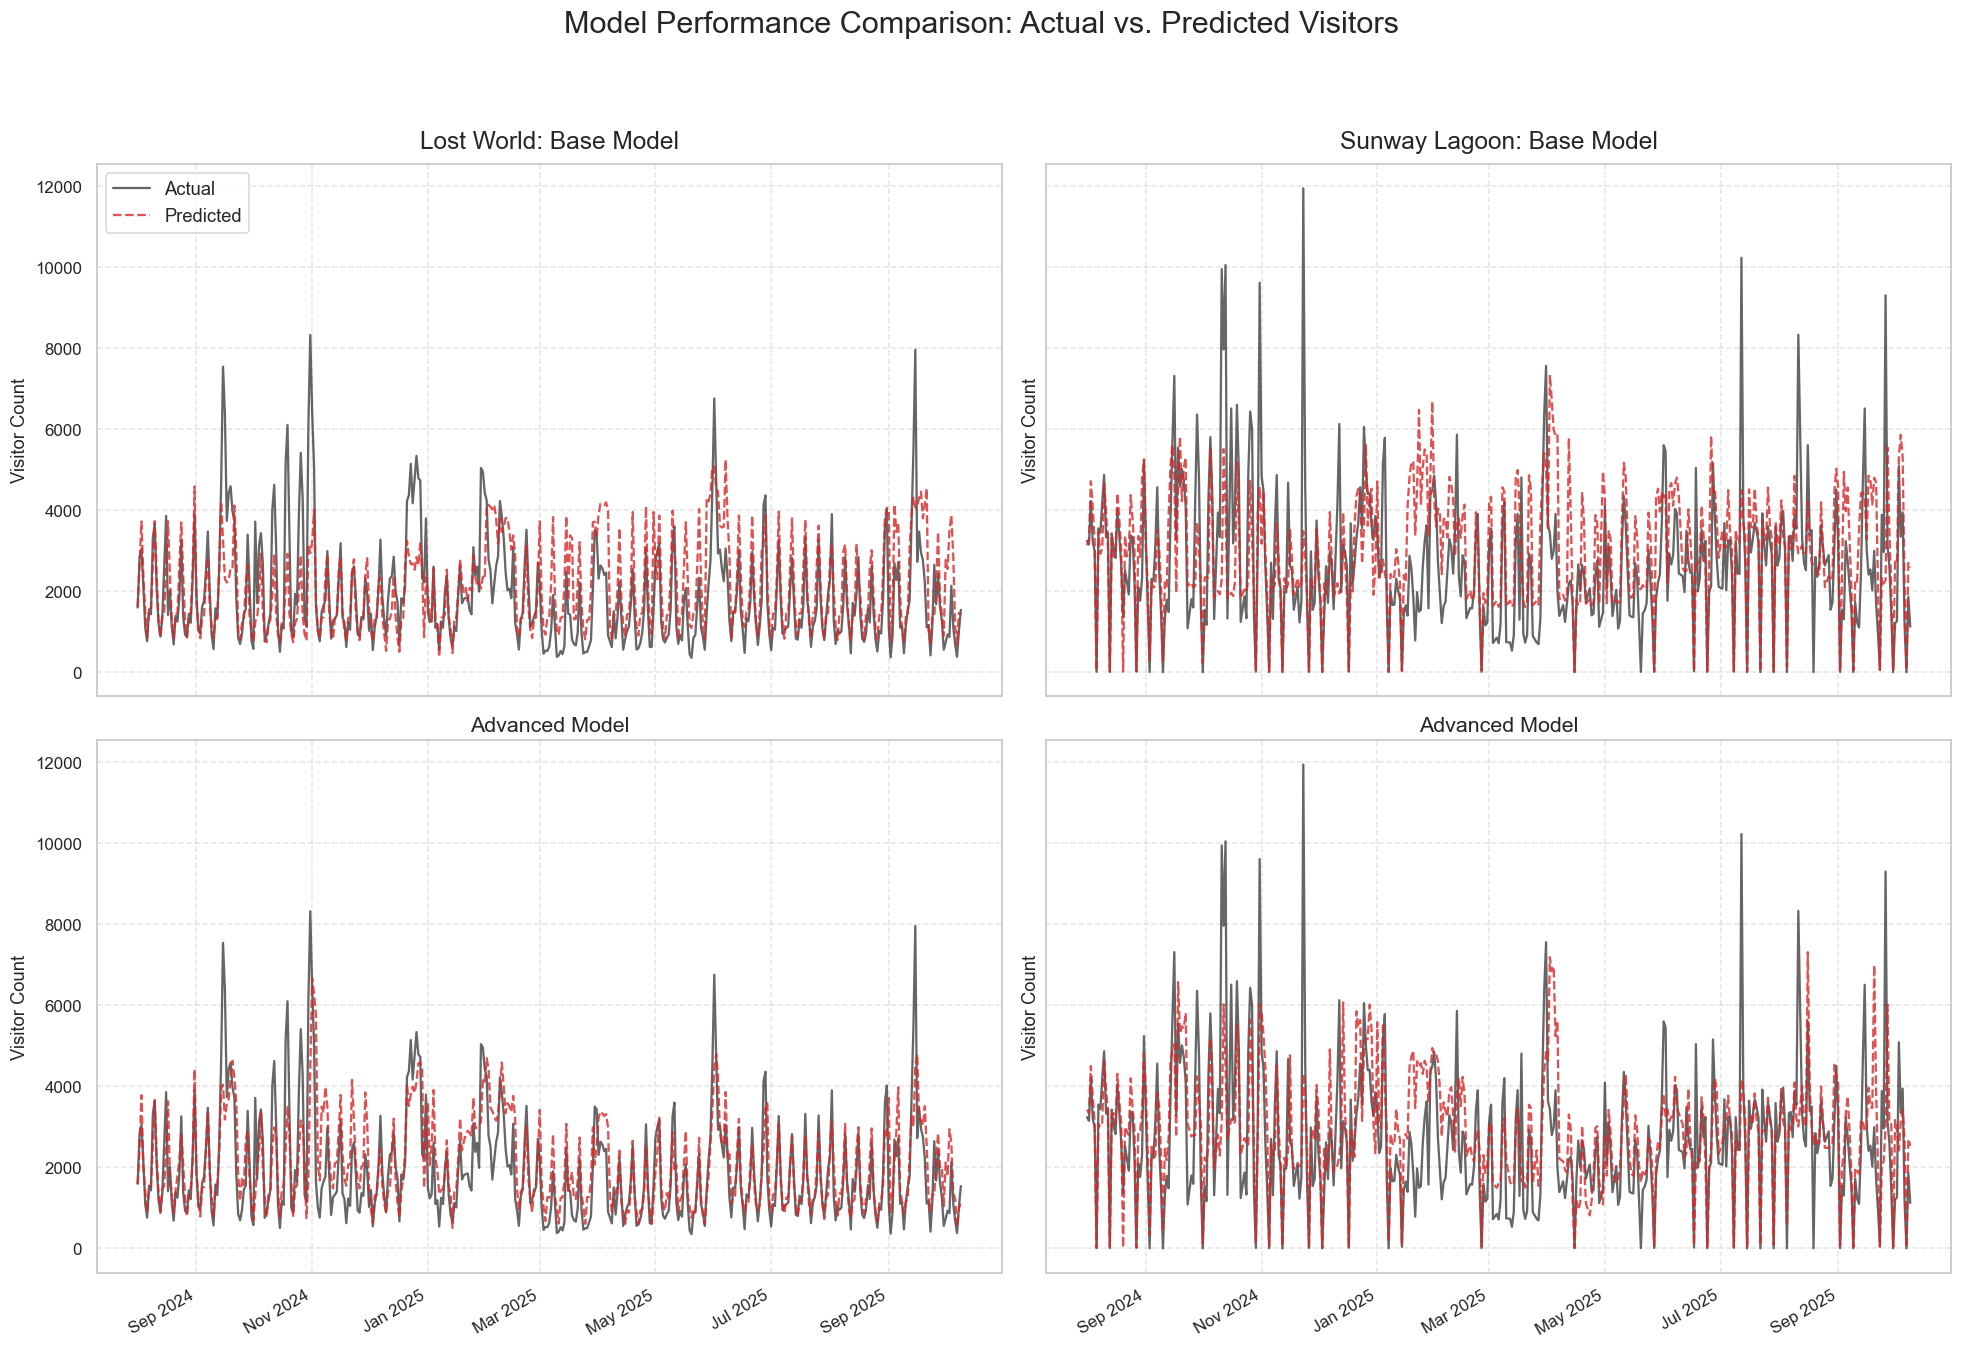

In [13]:
# Visualize the prediction VS actual result
# 1. Combine all predictions into one DataFrame
all_predictions_df = pd.concat(all_predictions_list)
all_predictions_df['visit_date'] = pd.to_datetime(all_predictions_df['visit_date'])

# 2. Setup the 2x2 Grid
# We define our iterators: Model Types and Parks
model_types = ['Base Model', 'Advanced Model']
parks = all_predictions_df['park'].unique()

# Create subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey='row')
fig.suptitle('Model Performance Comparison: Actual vs. Predicted Visitors', fontsize=20, y=1.02)

# 3. Iterate through Grid Positions
plot_count = 0
for row, m_type in enumerate(model_types):
    for col, p_name in enumerate(parks):
        ax = axes[row, col]
        
        # Filter data for this specific plot (this park + this model)
        plot_data = all_predictions_df[
            (all_predictions_df['model_type'] == m_type) & 
            (all_predictions_df['park'] == p_name)
        ].sort_values('visit_date')
        
        # Plot Actual vs. Predicted
        ax.plot(plot_data['visit_date'], plot_data[target], label='Actual', color='black', alpha=0.6, linewidth=1.5)
        ax.plot(plot_data['visit_date'], plot_data['prediction'], label='Predicted', color='tab:red', linestyle='--', alpha=0.8, linewidth=1.5)
        
        # Chart Formatting
        if row == 0:
            ax.set_title(f'{p_name}: {m_type}', fontsize=16, pad=10)
        else:
            ax.set_title(f'{m_type}', fontsize=14)
            
        ax.set_ylabel('Visitor Count', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Only show legend on the first plot to avoid clutter
        if plot_count == 0:
            ax.legend(fontsize=12, loc='upper left')
        
        plot_count += 1

# 4. Final Layout Adjustments
# Format the x-axis to show months clearly
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Tick every 2 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Format: 'Jan 2024'
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right') # Rotate labels

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to fit main title
plt.show()

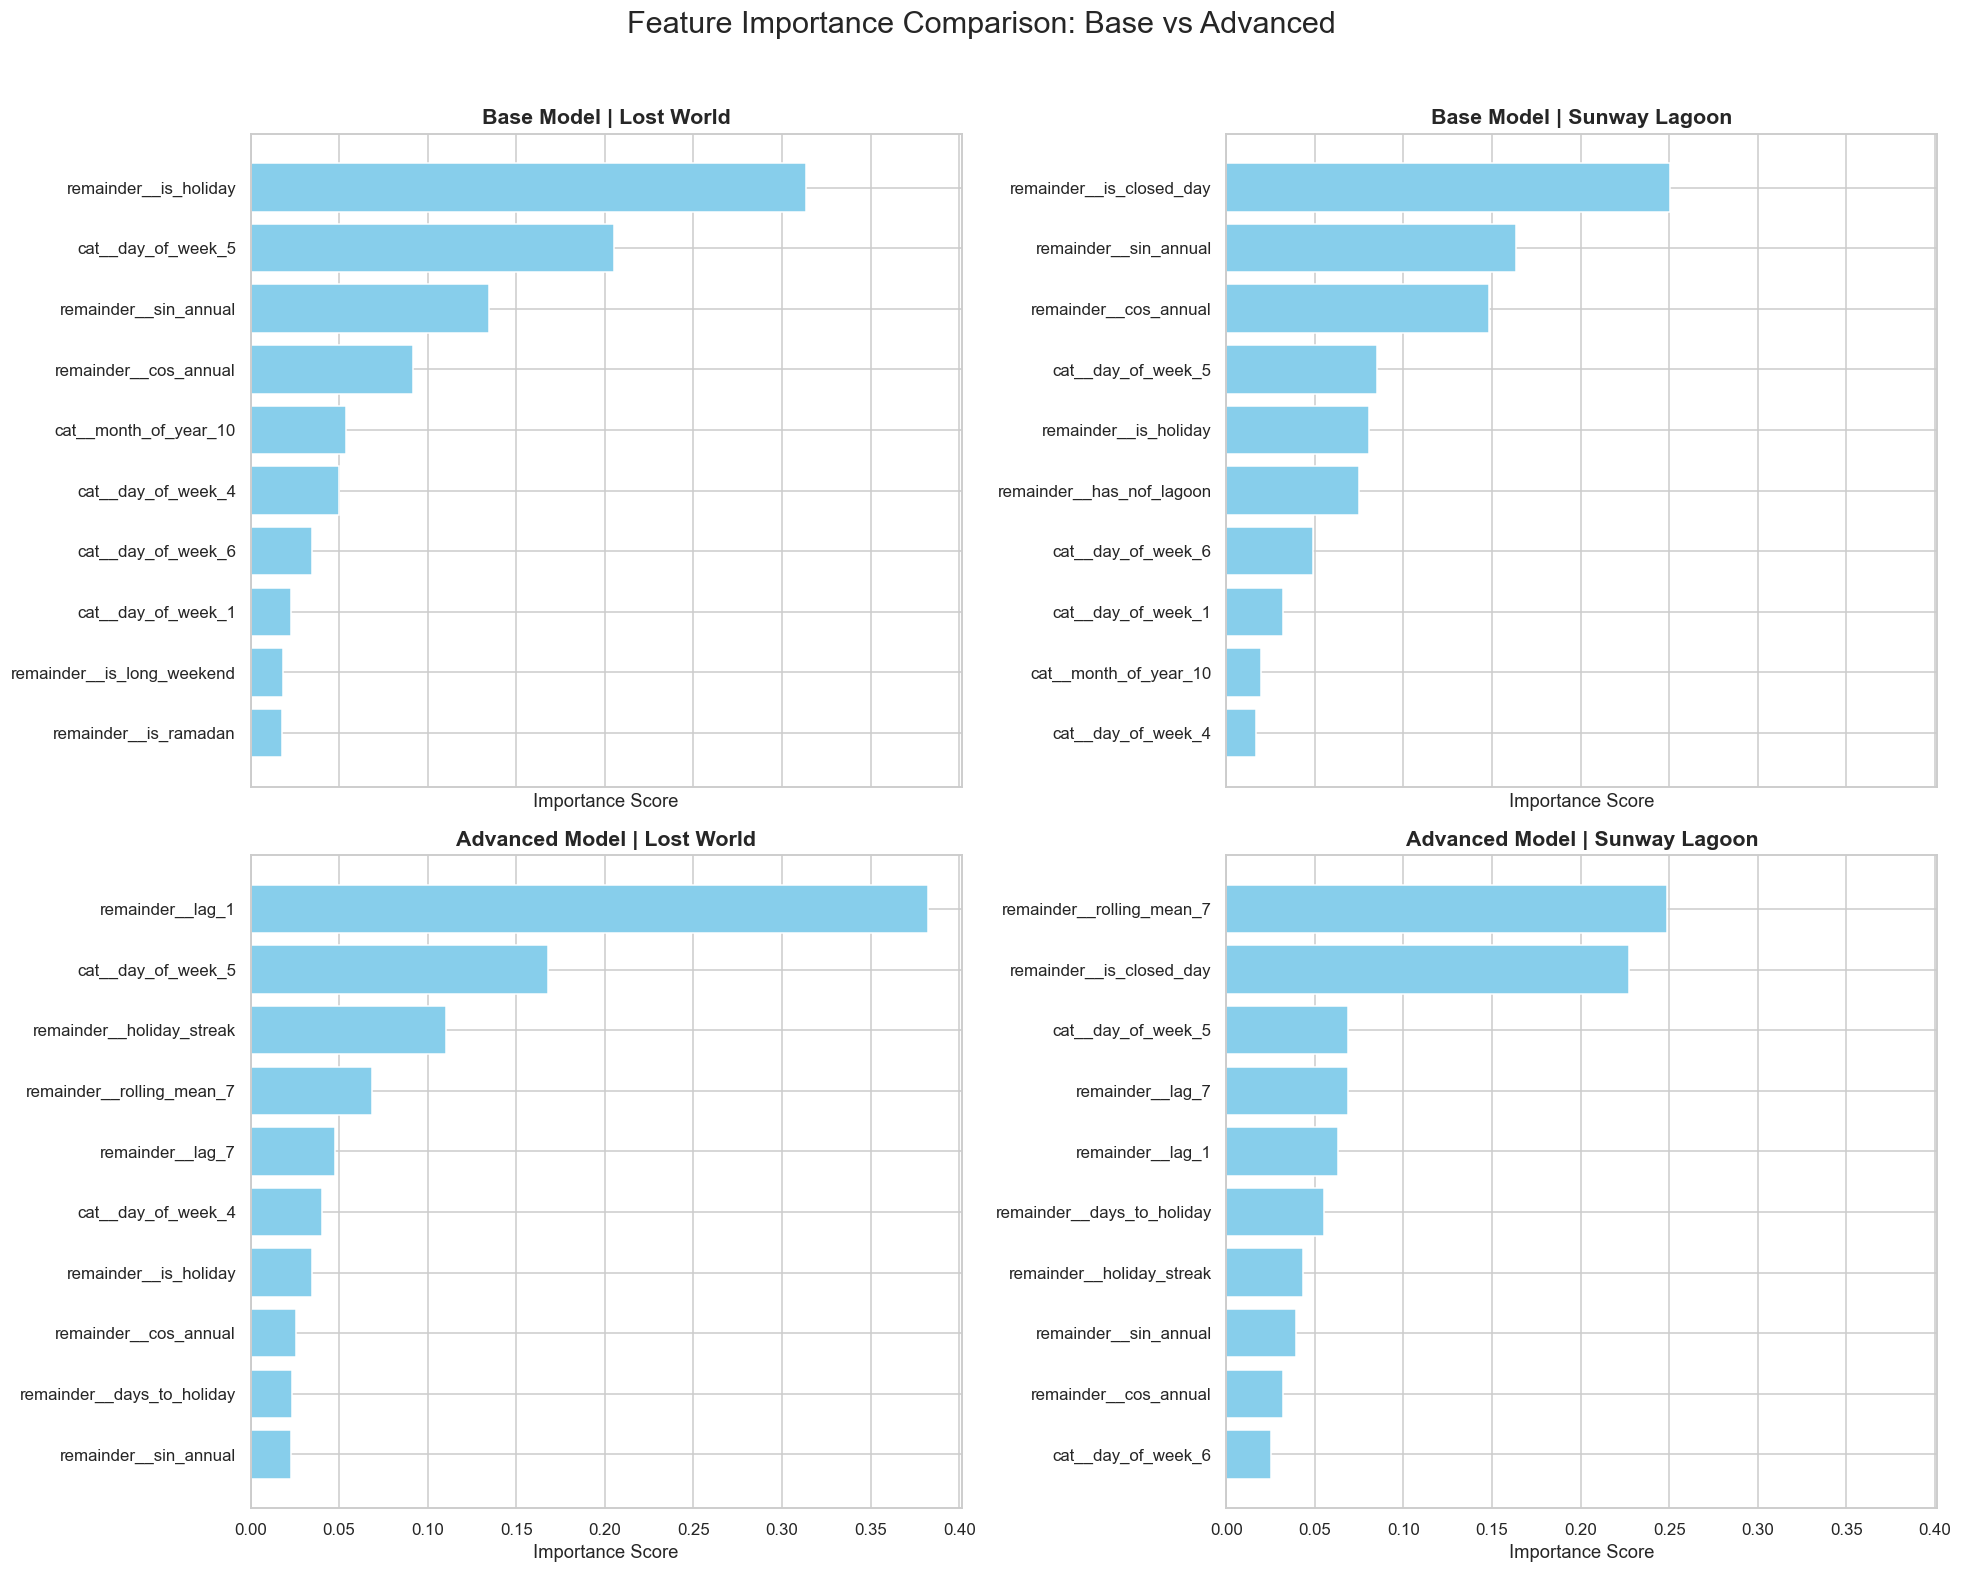

In [14]:
# Feature importance plot

# 1. Setup the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True)
fig.suptitle('Feature Importance Comparison: Base vs Advanced', fontsize=20, y=1.02)

# Define the grid structure (Row 0 = Base, Row 1 = Advanced)
model_types = ['Base Model', 'Advanced Model']
parks = sorted(dat['park'].unique()) # Ensures order (e.g., Lost World, Sunway)

for row, m_type in enumerate(model_types):
    for col, p in enumerate(parks):
        ax = axes[row, col]
        
        # Get data from the dictionary
        key = (m_type, p)
        if key in final_importances:
            df = final_importances[key].head(10) # Top 10 features
            ax.barh(df['Feature'], df['Importance'], color='skyblue')
            ax.set_title(f"{m_type} | {p}", fontsize=14, fontweight='bold')
            ax.invert_yaxis()
            ax.set_xlabel("Importance Score")
        else:
            ax.text(0.5, 0.5, 'No data', ha='center')

plt.tight_layout()
plt.show()

## XGBoost

In [19]:
from xgboost import XGBRegressor

# 1. Define feature groups
# Ensure numeric_features_base contains your initial features
features_base = cat_features_no_park + numeric_features
features_advanced = cat_features_no_park + numeric_features + ['days_to_holiday', 'is_payday_window', 'holiday_streak', 'lag_1', 'lag_7', 'rolling_mean_7']

# 2. Store them in a dictionary
model_configs = {
    "Base Model": features_base,
    "Advanced Model": features_advanced
}

# 3. Initialize storage containers
results = []
final_importances = {}
all_predictions_list = []

# 4. Training Loop
months = sorted(dat["visit_date"].dt.to_period("M").unique())
parks = dat['park'].unique()

for config_name, feature_list in model_configs.items():
    print(f"Training {config_name} with XGBoost...")
    
    # Define preprocessor inside loop to reset state for each model config
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
        ],
        remainder='passthrough'
    )
    
    for i in range(6, len(months) - 1):
        train_end = months[i].to_timestamp(how='end')
        train_df_full = dat[dat["visit_date"] <= train_end]
        test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
        
        for p in parks:
            train_df = train_df_full[train_df_full['park'] == p]
            test_df = test_df_full[test_df_full['park'] == p]
            
            if len(train_df) == 0 or len(test_df) == 0:
                continue
                
            # Define Pipeline with XGBoost
            model = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    objective='reg:absoluteerror', 
                    random_state=42,
                    n_jobs=-1
                ))
            ])
            
            # Train
            model.fit(train_df[feature_list], train_df[target])
            
            # Capture Importances
            fitted_preprocessor = model.named_steps['preprocessor']
            fitted_regressor = model.named_steps['regressor']
            feature_names = fitted_preprocessor.get_feature_names_out(feature_list)
            importances = fitted_regressor.feature_importances_
            
            final_importances[(config_name, p)] = pd.DataFrame({
                'Feature': feature_names, 
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            
            # Predict
            pred = np.clip(model.predict(test_df[feature_list]), 0, None)

            # Capture predictions for plotting later
            p_df = test_df[['park', 'visit_date', target]].copy()
            p_df['prediction'] = pred
            p_df['model_type'] = config_name
            p_df['test_month'] = months[i+1]
            all_predictions_list.append(p_df)
            
            # Evaluate
            metrics = get_metrics(test_df[target], pred, None)
            metrics["park"] = p
            metrics["model_type"] = config_name
            results.append(metrics)

# 5. Generate Summary Table
results_df = pd.DataFrame(results)
summary = results_df.groupby(["model_type", "park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Comprehensive Model Comparison (XGBoost) ===")
print(summary)

Training Base Model with XGBoost...
Training Advanced Model with XGBoost...

=== Comprehensive Model Comparison (XGBoost) ===
                              avg_wmape  std_wmape    avg_mae  avg_bias  n_folds
model_type     park                                                             
Advanced Model Lost World        0.3151     0.1262   576.9358  159.2993       15
               Sunway Lagoon     0.3381     0.1095   900.8623  137.7695       15
Base Model     Lost World        0.4396     0.2149   778.5666  190.3891       15
               Sunway Lagoon     0.4151     0.2220  1094.8796  251.6498       15


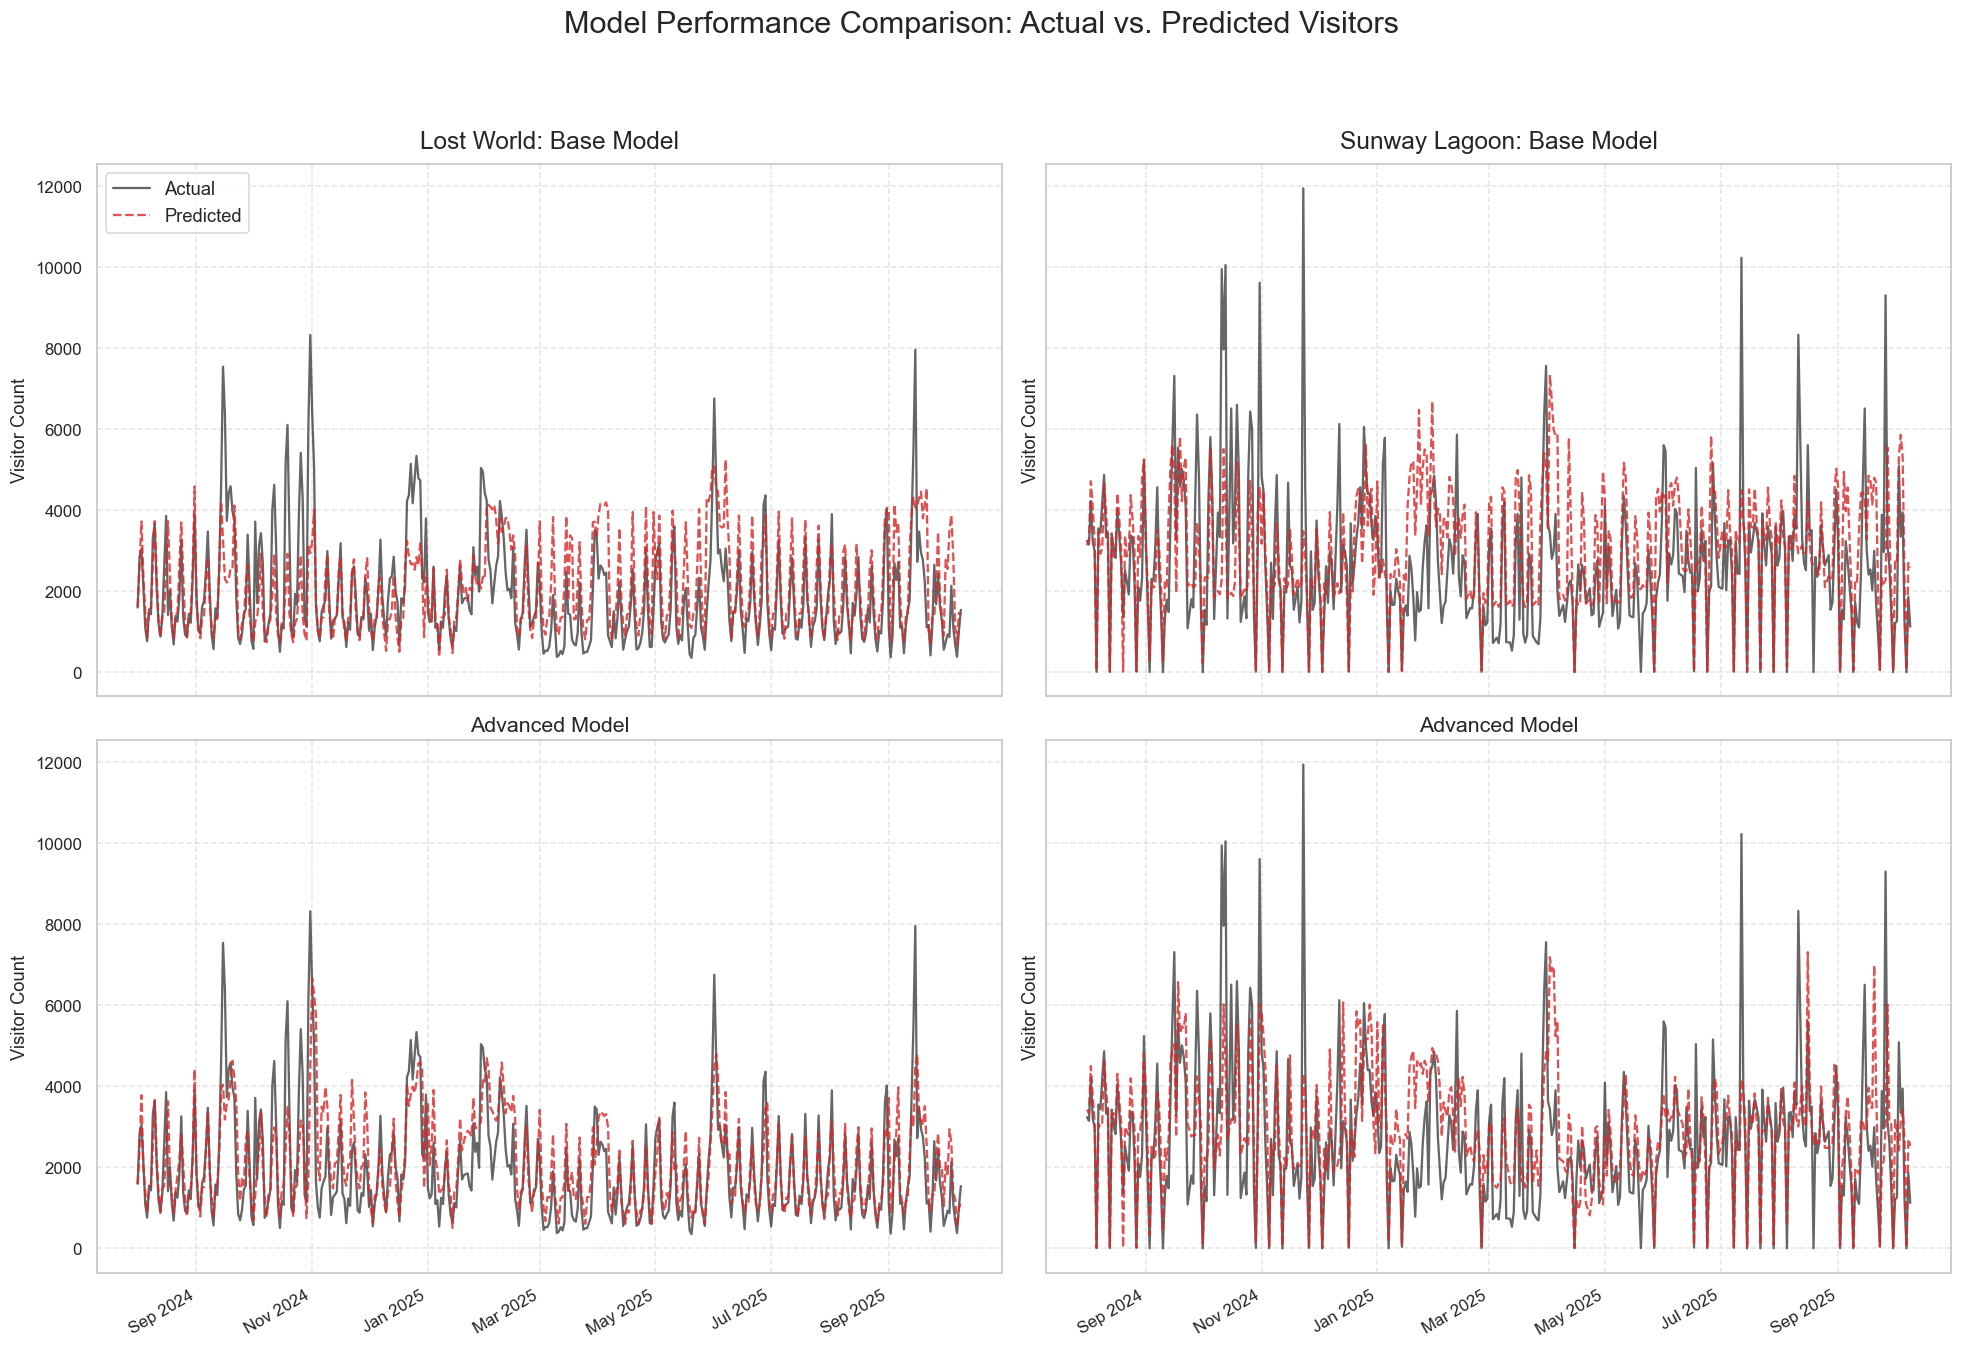

In [15]:
# Visualize the prediction VS actual result
# 1. Combine all predictions into one DataFrame
all_predictions_df = pd.concat(all_predictions_list)
all_predictions_df['visit_date'] = pd.to_datetime(all_predictions_df['visit_date'])

# 2. Setup the 2x2 Grid
# We define our iterators: Model Types and Parks
model_types = ['Base Model', 'Advanced Model']
parks = all_predictions_df['park'].unique()

# Create subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey='row')
fig.suptitle('Model Performance Comparison: Actual vs. Predicted Visitors', fontsize=20, y=1.02)

# 3. Iterate through Grid Positions
plot_count = 0
for row, m_type in enumerate(model_types):
    for col, p_name in enumerate(parks):
        ax = axes[row, col]
        
        # Filter data for this specific plot (this park + this model)
        plot_data = all_predictions_df[
            (all_predictions_df['model_type'] == m_type) & 
            (all_predictions_df['park'] == p_name)
        ].sort_values('visit_date')
        
        # Plot Actual vs. Predicted
        ax.plot(plot_data['visit_date'], plot_data[target], label='Actual', color='black', alpha=0.6, linewidth=1.5)
        ax.plot(plot_data['visit_date'], plot_data['prediction'], label='Predicted', color='tab:red', linestyle='--', alpha=0.8, linewidth=1.5)
        
        # Chart Formatting
        if row == 0:
            ax.set_title(f'{p_name}: {m_type}', fontsize=16, pad=10)
        else:
            ax.set_title(f'{m_type}', fontsize=14)
            
        ax.set_ylabel('Visitor Count', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Only show legend on the first plot to avoid clutter
        if plot_count == 0:
            ax.legend(fontsize=12, loc='upper left')
        
        plot_count += 1

# 4. Final Layout Adjustments
# Format the x-axis to show months clearly
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Tick every 2 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Format: 'Jan 2024'
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right') # Rotate labels

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to fit main title
plt.show()

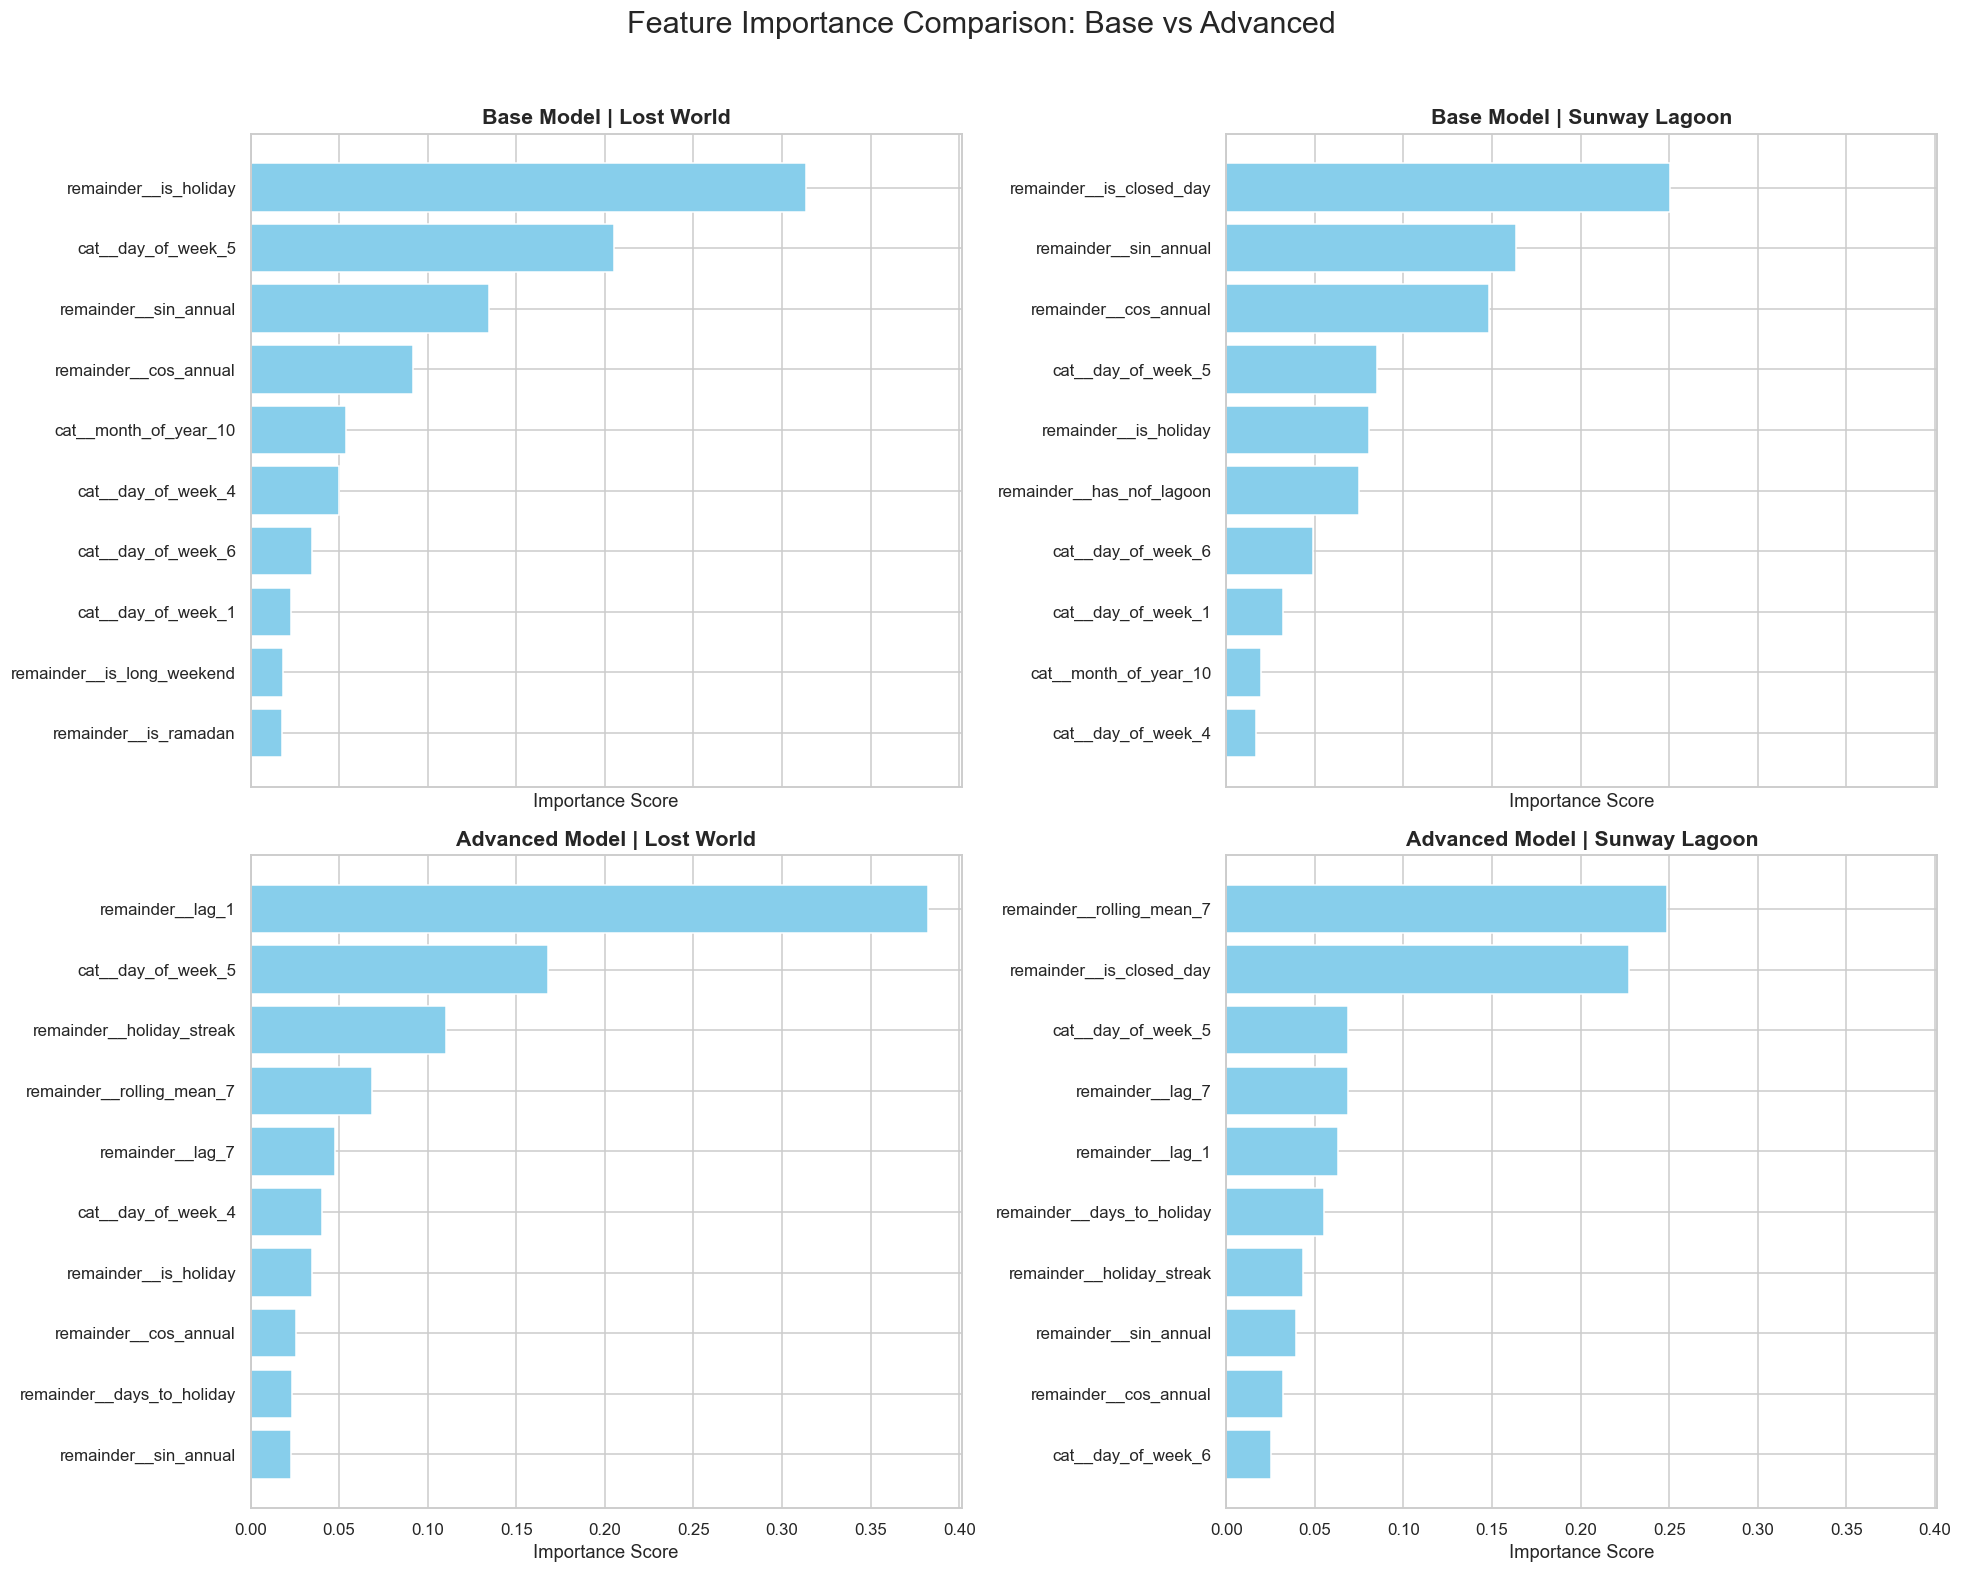

In [16]:
# Feature importance plot

# 1. Setup the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True)
fig.suptitle('Feature Importance Comparison: Base vs Advanced', fontsize=20, y=1.02)

# Define the grid structure (Row 0 = Base, Row 1 = Advanced)
model_types = ['Base Model', 'Advanced Model']
parks = sorted(dat['park'].unique()) # Ensures order (e.g., Lost World, Sunway)

for row, m_type in enumerate(model_types):
    for col, p in enumerate(parks):
        ax = axes[row, col]
        
        # Get data from the dictionary
        key = (m_type, p)
        if key in final_importances:
            df = final_importances[key].head(10) # Top 10 features
            ax.barh(df['Feature'], df['Importance'], color='skyblue')
            ax.set_title(f"{m_type} | {p}", fontsize=14, fontweight='bold')
            ax.invert_yaxis()
            ax.set_xlabel("Importance Score")
        else:
            ax.text(0.5, 0.5, 'No data', ha='center')

plt.tight_layout()
plt.show()

## Light GBM

In [17]:
# Installing light gbm
!pip install lightgbm

In [22]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

# 1. Define feature groups (Unchanged)
features_base = cat_features_no_park + numeric_features
features_advanced = cat_features_no_park + numeric_features + ['days_to_holiday', 'is_payday_window', 'holiday_streak', 'lag_1', 'lag_7', 'rolling_mean_7']

# 2. Store them in a dictionary
model_configs = {
    "Base Model": features_base,
    "Advanced Model": features_advanced
}

# 3. Initialize storage containers
results = []
final_importances = {}
all_predictions_list = []

# 4. Training Loop
months = sorted(dat["visit_date"].dt.to_period("M").unique())
parks = dat['park'].unique()

for config_name, feature_list in model_configs.items():
    print(f"Training {config_name} with LightGBM...")
    
    # Define preprocessor inside loop
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
        ],
        remainder='passthrough'
    )
    
    for i in range(6, len(months) - 1):
        train_end = months[i].to_timestamp(how='end')
        train_df_full = dat[dat["visit_date"] <= train_end]
        test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
        
        for p in parks:
            train_df = train_df_full[train_df_full['park'] == p]
            test_df = test_df_full[test_df_full['park'] == p]
            
            if len(train_df) == 0 or len(test_df) == 0:
                continue
                
            # Define Pipeline with LightGBM
            model = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    objective='regression_l1', # Equivalent to absolute error
                    random_state=42,
                    n_jobs=-1,
                    importance_type='gain',     # Switched to 'gain' for better insight
                    verbosity=-1                # Keeps the console clean
                ))
            ])
            
            # Train
            model.fit(train_df[feature_list], train_df[target])
            
            # Capture Importances
            fitted_preprocessor = model.named_steps['preprocessor']
            fitted_regressor = model.named_steps['regressor']
            
            # Get feature names from the transformer
            feature_names = fitted_preprocessor.get_feature_names_out(feature_list)
            importances = fitted_regressor.feature_importances_
            
            final_importances[(config_name, p)] = pd.DataFrame({
                'Feature': feature_names, 
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            
            # Predict
            pred = np.clip(model.predict(test_df[feature_list]), 0, None)

            # Capture predictions
            p_df = test_df[['park', 'visit_date', target]].copy()
            p_df['prediction'] = pred
            p_df['model_type'] = config_name
            p_df['test_month'] = months[i+1]
            all_predictions_list.append(p_df)
            
            # Evaluate
            metrics = get_metrics(test_df[target], pred, None)
            metrics["park"] = p
            metrics["model_type"] = config_name
            results.append(metrics)

# 5. Generate Summary Table (Unchanged)
results_df = pd.DataFrame(results)
summary = results_df.groupby(["model_type", "park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Comprehensive Model Comparison (LightGBM) ===")
print(summary)

Training Base Model with LightGBM...
Training Advanced Model with LightGBM...

=== Comprehensive Model Comparison (LightGBM) ===
                              avg_wmape  std_wmape    avg_mae  avg_bias  n_folds
model_type     park                                                             
Advanced Model Lost World        0.2560     0.0885   483.0864   23.3380       15
               Sunway Lagoon     0.3108     0.1028   841.4714  -68.9779       15
Base Model     Lost World        0.4302     0.2022   760.7467  230.9147       15
               Sunway Lagoon     0.3866     0.1438  1024.8612  206.8018       15


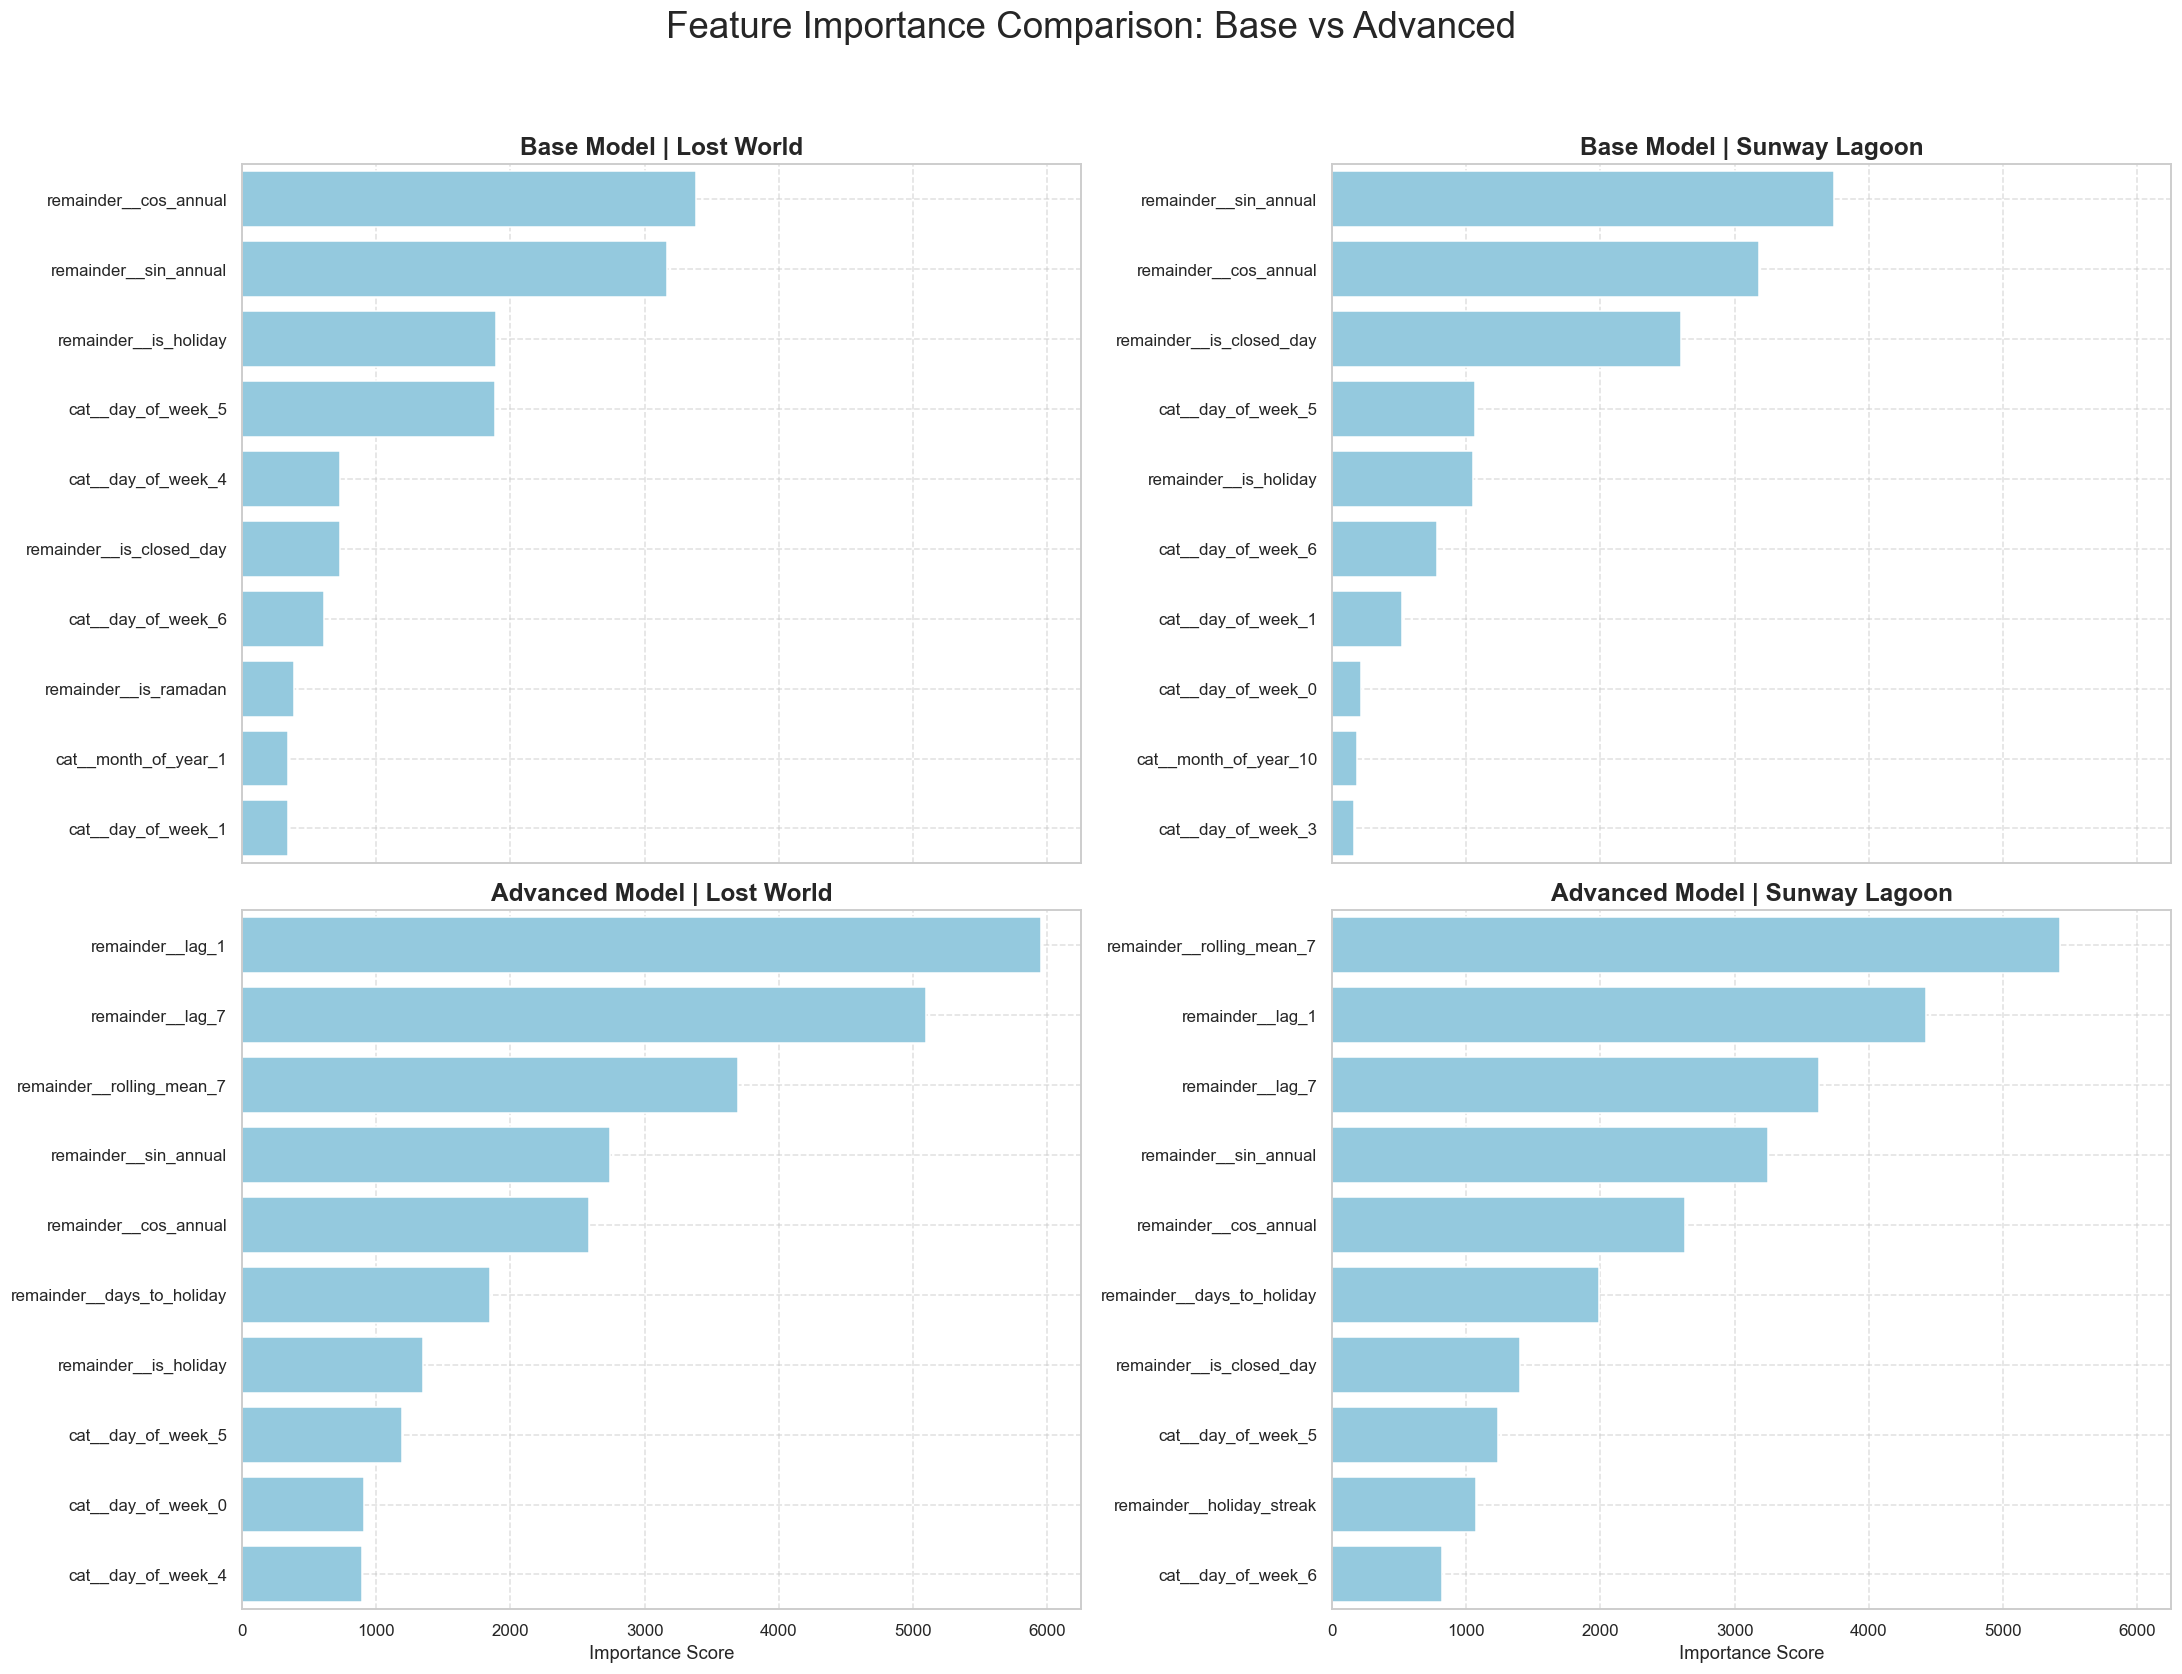

In [23]:
# Plotting feature importance
# 1. Reconstruct the dataframe with Model and Park labels
# (Since final_importances uses (config_name, p) as keys)
all_imp_list = []
for (model_name, park_name), df_imp in final_importances.items():
    temp_df = df_imp.copy()
    temp_df['model_type'] = model_name
    temp_df['park'] = park_name
    all_imp_list.append(temp_df)

full_imp_df = pd.concat(all_imp_list)

# 2. Average the importance across folds (but keep Model and Park separate)
plot_df = full_imp_df.groupby(['model_type', 'park', 'Feature'])['Importance'].mean().reset_index()

# 3. Setup the 2x2 Figure
fig, axes = plt.subplots(2, 2, figsize=(20, 16), sharex=True)
fig.suptitle('Feature Importance Comparison: Base vs Advanced', fontsize=24)

# Define the grid mapping
configs = ["Base Model", "Advanced Model"]
parks = ["Lost World", "Sunway Lagoon"]

# 4. Populate the Subplots
for row, model_name in enumerate(configs):
    for col, park_name in enumerate(parks):
        ax = axes[row, col]
        
        # Filter for this specific subplot
        subset = plot_df[(plot_df['model_type'] == model_name) & 
                         (plot_df['park'] == park_name)]
        
        # Sort and take top 10 to match the screenshot style
        subset = subset.sort_values('Importance', ascending=False).head(10)
        
        # Create the barplot
        sns.barplot(
            data=subset, 
            x='Importance', 
            y='Feature', 
            ax=ax, 
            color='skyblue' # Matches the light blue in your screenshot
        )
        
        # Formatting
        ax.set_title(f"{model_name} | {park_name}", fontsize=16, fontweight='bold')
        ax.set_xlabel("Importance Score" if row == 1 else "")
        ax.set_ylabel("")
        ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Goal: To reduce our average wmape to 0.20. Three options:
From this onwards,we will use Light BGM as our central model for the analysis, since it performed the best in terms of average wmape.

1. Hyperparameter tuning: increasing learning rate and reducing the number of tree estimators
2. More feature engineering using current available seasons time to capture the shape/pattern of the seasons
3. Any extra data/variables we could obtain from the dataset

## Hyperparameter tuning
1. n_estimators
- number of trees in light gbm
- number of times/chances for the model to correct themselves from the error in the previous tree
- too many trees will result in overfitting, because the model start memorizing the patterns from the error

2. learning_rate
- how much we actually change our total prediction based on that tree's finding
- the weight of the steps the trees take to reach the optimal solutions
- lower learning rate --> more cautious in learning and capturing the pattern

In [28]:
# Method 1: Hyperparameter tuning
# 1. Define feature groups (Unchanged)
features_base = cat_features_no_park + numeric_features
features_advanced = cat_features_no_park + numeric_features + ['days_to_holiday', 'is_payday_window', 'holiday_streak', 'lag_1', 'lag_7', 'rolling_mean_7']

# 2. Store them in a dictionary
model_configs = {
    "Base Model": features_base,
    "Advanced Model": features_advanced
}

# 3. Initialize storage containers
results = []
final_importances = {}
all_predictions_list = []

# 4. Training Loop
months = sorted(dat["visit_date"].dt.to_period("M").unique())
parks = dat['park'].unique()

for config_name, feature_list in model_configs.items():
    print(f"Training {config_name} with LightGBM...")
    
    # Define preprocessor inside loop
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
        ],
        remainder='passthrough'
    )
    
    for i in range(6, len(months) - 1):
        train_end = months[i].to_timestamp(how='end')
        train_df_full = dat[dat["visit_date"] <= train_end]
        test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
        
        for p in parks:
            train_df = train_df_full[train_df_full['park'] == p]
            test_df = test_df_full[test_df_full['park'] == p]
            
            if len(train_df) == 0 or len(test_df) == 0:
                continue
                
            # Define Pipeline with LightGBM
            model = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', LGBMRegressor(
                    n_estimators=2000,        # Not worry too much about the risk of overfitting
                    learning_rate=0.005,       # Be cautious in learning
                    max_depth=6,
                    objective='regression_l1', # Equivalent to absolute error
                    random_state=42,
                    n_jobs=-1,
                    importance_type='gain',     # Switched to 'gain' for better insight
                    verbosity=-1                # Keeps the console clean
                ))
            ])
            
            # Train

            # 1. Manually fit the preprocessor first so it's ready for the eval_set
            preprocessor.fit(train_df[feature_list])

            # 2. Transform the test data so LightGBM can read it during training
            X_test_transformed = preprocessor.transform(test_df[feature_list])

            model.fit(train_df[feature_list], train_df[target],
                      # Tell the pipeline these belong to the 'regressor' step:
                      regressor__eval_set=[(X_test_transformed, test_df[target])],
                      regressor__callbacks=[lgb.early_stopping(stopping_rounds=50)])
            
            # Capture Importances
            fitted_preprocessor = model.named_steps['preprocessor']
            fitted_regressor = model.named_steps['regressor']
            
            # Get feature names from the transformer
            feature_names = fitted_preprocessor.get_feature_names_out(feature_list)
            importances = fitted_regressor.feature_importances_
            
            final_importances[(config_name, p)] = pd.DataFrame({
                'Feature': feature_names, 
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            
            # Predict
            pred = np.clip(model.predict(test_df[feature_list]), 0, None)

            # Capture predictions
            p_df = test_df[['park', 'visit_date', target]].copy()
            p_df['prediction'] = pred
            p_df['model_type'] = config_name
            p_df['test_month'] = months[i+1]
            all_predictions_list.append(p_df)
            
            # Evaluate
            metrics = get_metrics(test_df[target], pred, None)
            metrics["park"] = p
            metrics["model_type"] = config_name
            results.append(metrics)

# 5. Generate Summary Table (Unchanged)
results_df = pd.DataFrame(results)
summary = results_df.groupby(["model_type", "park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Comprehensive Model Comparison (LightGBM) ===")
print(summary)

Training Base Model with LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[502]	valid_0's l1: 427.126
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[912]	valid_0's l1: 570.333
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[683]	valid_0's l1: 720.302
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 905.759
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[535]	valid_0's l1: 1080.9
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[596]	valid_0's l1: 2134.89
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[328]	valid_0's l1: 445.793
Training until validation scores don't improve for 50 rounds
Early stopping, best 

## More feature engineering, but make the avg wmape higher

In [ ]:
# Method 2: Adding more variables within the current dataset (Feature Engineering) to get more seasonality pattern
# 1. Interaction: Is it a holiday AND a weekend?
dat['holiday_weekend'] = dat['is_holiday'] * dat['is_long_weekend']

# 2. Volatility: How much did the crowd fluctuate this week?
dat['rolling_std_7'] = dat.groupby('park')['visitors'].transform(lambda x: x.shift(1).rolling(window=7).std())

# 3. Momentum: Is the trend going up or down?
# (7-day average vs 21-day average)
rolling_7 = dat.groupby('park')['visitors'].transform(lambda x: x.shift(1).rolling(window=7).mean())
rolling_21 = dat.groupby('park')['visitors'].transform(lambda x: x.shift(1).rolling(window=21).mean())
dat['trend_velocity'] = rolling_7 - rolling_21

In [30]:
# 1. Define feature groups
features_base = cat_features_no_park + numeric_features
features_advanced = cat_features_no_park + numeric_features + ['holiday_weekend', 'rolling_std_7', 'trend_velocity']

# 2. Store them in a dictionary
model_configs = {
    "Base Model": features_base,
    "Advanced Model": features_advanced
}

# 3. Initialize storage containers
results = []
final_importances = {}
all_predictions_list = []

# 4. Training Loop
months = sorted(dat["visit_date"].dt.to_period("M").unique())
parks = dat['park'].unique()

for config_name, feature_list in model_configs.items():
    print(f"Training {config_name} with LightGBM...")
    
    # Define preprocessor inside loop
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_no_park)
        ],
        remainder='passthrough'
    )
    
    for i in range(6, len(months) - 1):
        train_end = months[i].to_timestamp(how='end')
        train_df_full = dat[dat["visit_date"] <= train_end]
        test_df_full = dat[dat["visit_date"].dt.to_period("M") == months[i+1]]
        
        for p in parks:
            train_df = train_df_full[train_df_full['park'] == p]
            test_df = test_df_full[test_df_full['park'] == p]
            
            if len(train_df) == 0 or len(test_df) == 0:
                continue
                
            # Define Pipeline with LightGBM
            model = Pipeline([
                ('preprocessor', preprocessor),
                ('regressor', LGBMRegressor(
                    n_estimators=2000,        # Not worry too much about the risk of overfitting
                    learning_rate=0.005,       # Be cautious in learning
                    max_depth=6,
                    objective='regression_l1', # Equivalent to absolute error
                    random_state=42,
                    n_jobs=-1,
                    importance_type='gain',     # Switched to 'gain' for better insight
                    verbosity=-1                # Keeps the console clean
                ))
            ])
            
            # Train

            # 1. Manually fit the preprocessor first so it's ready for the eval_set
            preprocessor.fit(train_df[feature_list])

            # 2. Transform the test data so LightGBM can read it during training
            X_test_transformed = preprocessor.transform(test_df[feature_list])

            model.fit(train_df[feature_list], train_df[target],
                      # Tell the pipeline these belong to the 'regressor' step:
                      regressor__eval_set=[(X_test_transformed, test_df[target])],
                      regressor__callbacks=[lgb.early_stopping(stopping_rounds=50)])
            
            # Capture Importances
            fitted_preprocessor = model.named_steps['preprocessor']
            fitted_regressor = model.named_steps['regressor']
            
            # Get feature names from the transformer
            feature_names = fitted_preprocessor.get_feature_names_out(feature_list)
            importances = fitted_regressor.feature_importances_
            
            final_importances[(config_name, p)] = pd.DataFrame({
                'Feature': feature_names, 
                'Importance': importances
            }).sort_values(by='Importance', ascending=False)
            
            # Predict
            pred = np.clip(model.predict(test_df[feature_list]), 0, None)

            # Capture predictions
            p_df = test_df[['park', 'visit_date', target]].copy()
            p_df['prediction'] = pred
            p_df['model_type'] = config_name
            p_df['test_month'] = months[i+1]
            all_predictions_list.append(p_df)
            
            # Evaluate
            metrics = get_metrics(test_df[target], pred, None)
            metrics["park"] = p
            metrics["model_type"] = config_name
            results.append(metrics)

# 5. Generate Summary Table (Unchanged)
results_df = pd.DataFrame(results)
summary = results_df.groupby(["model_type", "park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Comprehensive Model Comparison (LightGBM) ===")
print(summary)

Training Base Model with LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[502]	valid_0's l1: 427.126
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[912]	valid_0's l1: 570.333
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[683]	valid_0's l1: 720.302
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 905.759
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[535]	valid_0's l1: 1080.9
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[596]	valid_0's l1: 2134.89
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[328]	valid_0's l1: 445.793
Training until validation scores don't improve for 50 rounds
Early stopping, best 

## Looking for extra information

- ActiveInd:	    Indicator weather record is active or not
- EventName:	    Name of the event
- StartDateTime:	Event start date and time
- EndDateTime:	Event end date and time
- Day_Night:   	Day or night classification
- Discount_ValidThru: Discount valid end date
- Discount_ValidFrom:	Discount valid start date
- DiscountName:	Name of the discount

In [33]:
CONFIG = {
    "DB_PATH":                  "theme_park_data.db",
    "TRAIN_START_TS":           "2023-12-31 16:00:00",
    "TRAIN_END_TS_EXCLUSIVE":   "2025-12-31 16:00:00",
    "PARK_ENVIRONMENTS":        (1, 2),
    "PRIMARY_METRIC":           "wmape",
    "MIN_TRAIN_MONTHS":         4,
    "TARGET_TRANSFORM":         "log1p",
    "SUCCESS_GATE_IMPROVEMENT": 0.10,   # >=10% WMAPE improvement vs B2
    "PARK_GUARDRAIL_MAX_DEGRADE": 0.03,
}

MONTH_LEVELS = list(range(1, 13))
DOW_LEVELS   = list(range(0, 7))          # 0=Mon ... 6=Sun
PARK_LEVELS  = ["Lost World", "Sunway Lagoon"]

# Ramadan windows — Islamic calendar, updated annually
RAMADAN_PERIODS: Dict[int, Tuple[str, str]] = {
    2022: ("2022-04-02", "2022-05-01"),
    2023: ("2023-03-23", "2023-04-20"),
    2024: ("2024-03-12", "2024-04-09"),
    2025: ("2025-03-01", "2025-03-29"),
    2026: ("2026-02-18", "2026-03-19"),
}

# Price elasticity assumptions for sensitivity testing
# Cannot be estimated from data — pricing has been fixed historically.
# Values drawn from published leisure/theme-park demand elasticity literature.
ELASTICITY_SCENARIOS: Dict[str, float] = {
    "inelastic (−0.3)":  -0.3,   # families committed; price-insensitive
    "moderate  (−0.8)":  -0.8,   # reasonable central assumption
    "elastic   (−1.2)":  -1.2,   # price-sensitive day-trippers
}
BASE_ELASTICITY = -0.8           # default used in pipeline

CONFIG

{'DB_PATH': 'theme_park_data.db',
 'TRAIN_START_TS': '2023-12-31 16:00:00',
 'TRAIN_END_TS_EXCLUSIVE': '2025-12-31 16:00:00',
 'PARK_ENVIRONMENTS': (1, 2),
 'PRIMARY_METRIC': 'wmape',
 'MIN_TRAIN_MONTHS': 4,
 'TARGET_TRANSFORM': 'log1p',
 'SUCCESS_GATE_IMPROVEMENT': 0.1,
 'PARK_GUARDRAIL_MAX_DEGRADE': 0.03}

In [35]:
con = duckdb.connect("theme_park_data.db")

In [39]:
# Extracting the 'Extra Information' view with visitor counts
extra_info_sql = f"""
SELECT
    CAST(TranDate + INTERVAL '8 hours' AS DATE) AS visit_date,
    CASE 
        WHEN Environment = 1 THEN 'Sunway Lagoon'
        WHEN Environment = 2 THEN 'Lost World'
    END AS park,
    ActiveInd,
    EventName,
    StartDateTime,
    EndDateTime,
    Day_Night,
    Discount_ValidFrom,
    Discount_ValidThru,
    DiscountName,
    -- Aggregate metric
    CAST(SUM(Complete_QTY) AS INT) AS visitors
FROM theme_park_database
WHERE Environment IN {CONFIG['PARK_ENVIRONMENTS']}
  AND TranDate >= TIMESTAMP '{CONFIG['TRAIN_START_TS']}'
  AND TranDate <  TIMESTAMP '{CONFIG['TRAIN_END_TS_EXCLUSIVE']}'
GROUP BY 
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10
ORDER BY 
    visit_date ASC, 
    park ASC
"""

# Execute and load into a diagnostic DataFrame
df_extra_check = con.execute(extra_info_sql).df()

# Basic preprocessing for readability
df_extra_check['visit_date'] = pd.to_datetime(df_extra_check['visit_date'])

# Display the structure
print(f"Total records found: {len(df_extra_check)}")
print("-" * 30)
display(df_extra_check.head(20))

Total records found: 1189266
------------------------------


,visit_date,park,ActiveInd,EventName,StartDateTime,EndDateTime,Day_Night,Discount_ValidFrom,Discount_ValidThru,DiscountName,visitors
0,2024-01-01,Lost World,Y,NaN,NaT,NaT,Day,NaT,NaT,NaN,4445
1,2024-01-01,Lost World,Y,,2024-01-01 09:44:25.677,2024-01-01 09:44:25.677,Day,NaT,NaT,,1
2,2024-01-01,Lost World,Y,,2024-01-01 02:42:11.303,2024-01-01 02:42:11.303,Day,NaT,NaT,,1
3,2024-01-01,Lost World,Y,,2024-01-01 05:14:18.820,2024-01-01 05:14:18.820,Day,NaT,NaT,,1
4,2024-01-01,Lost World,Y,,2024-01-01 12:00:01.653,2024-01-01 12:00:01.653,Night,NaT,NaT,,1
5,2024-01-01,Lost World,Y,NaN,NaT,NaT,Night,2023-12-31 16:00:00,2024-12-30 16:00:00,MP UP EP AP New MY PRK,4
6,2024-01-01,Lost World,Y,,2024-01-01 10:50:22.677,2024-01-01 10:50:22.677,Night,NaT,NaT,,1
7,2024-01-01,Lost World,Y,,2024-01-01 11:28:24.453,2024-01-01 11:28:24.453,Night,NaT,NaT,,1
8,2024-01-01,Lost World,Y,,2024-01-01 04:32:00.353,2024-01-01 04:32:00.353,Day,NaT,NaT,,1
9,2024-01-01,Lost World,Y,,2024-01-01 10:43:09.580,2024-01-01 10:43:09.580,Night,NaT,NaT,,1


In [42]:
df_extra_check['DiscountName'].unique()

<ArrowStringArray>
[                        nan,                          '',    'MP UP EP AP New MY PRK',                'OKU MY 50%',        'FNB Sunway Stf 15%',     'Retail Sunway Stf 10%',   'WS MyKad Promotion 2024',
        'MP UP Privileges 2',           'MyKad Rate 2024',    'MP AP Special Roadshow',
 ...
   'Potato Crisp RM10 Matta',      'NOF11 Staff Discount',     'Toys “R” Us Joint Pro',    'ParisBaguette Staff20%', 'Ult Pass ParisBaguette10%', 'Passport ParisBaguette10%',  'Ult Pass KLM - Tatto 10%',
 'ParisBaguette Buy3 Free 1', 'SVIP Retail Item Disc 10%',  'WS Screamfest 2025 MyKad']
Length: 231, dtype: str

In [43]:
df_extra_check['EventName'].unique()

<ArrowStringArray>
[                                  nan,                                    '',               'Equipment - Cabana LK',           'Equipment - Cabana Family',               'Equipment - Cabana SB',
     'Equipment - Cabana VIP Malicove',         'Equipment - Cabana Malicove',     'Night Park CNY 10/02/2024 (Sat)', 'Equipment - Cabana VIP Beach Bistro',     'Night Park CNY 11/02/2024 (Sun)',
 ...
    'NOF11 Xpress Lane 10/10/25 (FRI)',    'NOF11 Xpress Lane 25/10/25 (SAT)',    'NOF11 Xpress Lane 11/10/25 (SAT)',    'NOF11 Xpress Lane 26/09/25 (FRI)',    'NOF11 Xpress Lane 31/10/25 (FRI)',
    'NOF11 Xpress Lane 04/10/25 (SAT)',    'NOF11 Xpress Lane 05/10/25 (SUN)',    'NOF11 Xpress Lane 12/10/25 (SUN)',    'NOF11 Xpress Lane 02/11/25 (SUN)',           'Screamfest Admission 2025']
Length: 208, dtype: str

In [88]:
# Shows the event name AND how many rows it appears in
df_extra_check['EventName'].value_counts(dropna=False).to_frame()

,count
EventName,
,1133368
NaN,46014
Equipment - Cabana LK,592
Equipment - Cabana SB,443
Equipment - Cabana Malicove,425
...,...
NOF11 Vending Machine 17/10/25 (FRI),1
NOF11 Vending Machine 26/09/25 (FRI),1
NOF11 Vending Machine 03/10/25 (FRI),1


Based on the information above, decide to add:
- Binary (DiscountName)
- Binary (EventName)
- Binary (Day/Night)

In [45]:
# Aggregating to Park-Day-Session (Day/Night) grain
refined_sql = f"""
WITH daily_session AS (
    SELECT
        CAST(TranDate + INTERVAL '8 hours' AS DATE) AS visit_date,
        CASE 
            WHEN Environment = 1 THEN 'Sunway Lagoon'
            WHEN Environment = 2 THEN 'Lost World'
        END AS park,
        -- ii) Day/Night classification
        Day_Night,
        
        -- i) Total visitors for that specific date/park/session
        CAST(SUM(Complete_QTY) AS INT) AS total_visitors,
        
        -- iii) Binary indicators (1 if ANY record in this session has an event/discount)
        MAX(CASE WHEN EventName IS NOT NULL AND EventName <> '' THEN 1 ELSE 0 END) AS has_event,
        MAX(CASE WHEN DiscountName IS NOT NULL AND DiscountName <> '' THEN 1 ELSE 0 END) AS has_discount,
        
        -- Corrected function for DuckDB: STRING_AGG instead of LIST_AGG
        STRING_AGG(DISTINCT EventName, ', ') FILTER (WHERE EventName IS NOT NULL) AS event_list,
        STRING_AGG(DISTINCT DiscountName, ', ') FILTER (WHERE DiscountName IS NOT NULL) AS discount_list
        
    FROM theme_park_database
    WHERE Environment IN {CONFIG['PARK_ENVIRONMENTS']}
      AND TranDate >= TIMESTAMP '{CONFIG['TRAIN_START_TS']}'
      AND TranDate <  TIMESTAMP '{CONFIG['TRAIN_END_TS_EXCLUSIVE']}'
    GROUP BY 1, 2, 3
)
SELECT * FROM daily_session
ORDER BY visit_date ASC, park ASC, Day_Night DESC
"""

# Execute and load
df_sessions = con.execute(refined_sql).df()

# ii) Final encoding of Day_Night as Binary
# Day = 1, Night = 0
df_sessions['is_day_session'] = df_sessions['Day_Night'].map({'Day': 1, 'Night': 0}).fillna(0).astype(int)

# Clean up any NaNs in the lists to keep it tidy
df_sessions['event_list'] = df_sessions['event_list'].fillna('None')
df_sessions['discount_list'] = df_sessions['discount_list'].fillna('None')

display(df_sessions.head(10))

,visit_date,park,Day_Night,total_visitors,has_event,has_discount,event_list,discount_list,is_day_session
0,2024-01-01,Lost World,Night,2977,0,1,,"LWHotel Voucher 35% 2024, MP UP Privileges 2, ...",0
1,2024-01-01,Lost World,Day,5073,0,1,,"WS MyKad Promotion 2024, Sunway Staff WB 40% 2...",1
2,2024-01-01,Sunway Lagoon,Night,1057,0,1,,"San Francisco B1F1, SL FNB Passport 10%, CFL L...",0
3,2024-01-01,Sunway Lagoon,Day,11664,1,1,", Equipment - Cabana LK, Equipment - Cabana Fa...","Luggage Passport 20% Disc, Passport Hot Meal B...",1
4,2024-01-02,Lost World,Night,553,0,1,,"WS MyKad Promotion 2024, LWHotel Voucher 35% 2...",0
5,2024-01-02,Lost World,Day,514,0,1,,", WS Online Promotion 2024, WS MyKad Promotion...",1
6,2024-01-02,Sunway Lagoon,Night,4,1,0,Equipment - Cabana SB,None,0
7,2024-01-02,Sunway Lagoon,Day,304,1,1,Equipment - Cabana VIP Malicove,"B2C Online, Passport Online RM498",1
8,2024-01-03,Lost World,Night,1572,0,1,,"LWHotel Voucher 35% 2024, FNB Sunway Stf 15%, ...",0
9,2024-01-03,Lost World,Day,2948,0,1,,"MP EP Privileges, Retail Sunway Stf 10%, MP UP...",1


In [46]:
# Merging with holiday information

# 1. Ensure the join keys are the same type (Datetime)
dat['visit_date'] = pd.to_datetime(dat['visit_date'])
df_sessions['visit_date'] = pd.to_datetime(df_sessions['visit_date'])

# 2. Perform the merge
# We use 'left' join on df_sessions to keep the Day/Night granularity
# We join on both 'visit_date' and 'park' to ensure correct alignment
final_df = df_sessions.merge(
    dat.drop(columns=['visitors']), # Drop 'visitors' from dat to avoid duplicate columns
    on=['visit_date', 'park'],
    how='left'
)

# 3. Clean up the merged columns
# If some dates were missing in 'dat', the calendar features might be NaN. 
# We'll fill them with 0 as per your previous architecture.
binary_cols = [
    'is_school_holiday', 'is_public_holiday', 'is_holiday', 
    'is_closed_day', 'is_long_weekend', 'is_ramadan'
]

for col in binary_cols:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna(0).astype(int)

# 4. Final check
print(f"Original Dat Shape:      {dat.shape}")
print(f"Session Data Shape:      {df_sessions.shape}")
print(f"Final Merged Shape:      {final_df.shape}")
print("-" * 30)
print("Columns in final dataset:")
print(final_df.columns.tolist())

display(final_df.head(10))

Original Dat Shape:      (1273, 28)
Session Data Shape:      (2594, 9)
Final Merged Shape:      (2594, 34)
------------------------------
Columns in final dataset:
['visit_date', 'park', 'Day_Night', 'total_visitors', 'has_event', 'has_discount', 'event_list', 'discount_list', 'is_day_session', 'calendar_date', 'holiday_name', 'is_school_holiday', 'is_public_holiday', 'is_holiday', 'is_closed_day', 'is_long_weekend', 'is_ramadan', 'month_of_year', 'day_of_week', 'day_of_year', 'sin_annual', 'cos_annual', 'has_nof_lagoon', 'days_to_holiday', 'day_of_month', 'is_payday_window', 'holiday_streak', 'lag_1', 'lag_7', 'rolling_mean_7', 'holiday_weekend', 'rolling_std_7', 'trend_velocity', 'dist_to_payday']


,visit_date,park,Day_Night,total_visitors,has_event,has_discount,event_list,discount_list,is_day_session,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday,day_of_month,is_payday_window,holiday_streak,lag_1,lag_7,rolling_mean_7,holiday_weekend,rolling_std_7,trend_velocity,dist_to_payday
0,2024-01-01,Lost World,Night,2977,0,1,,"LWHotel Voucher 35% 2024, MP UP Privileges 2, ...",0,2024-01-01,New Year Day,0,1,1,0,1,0,1.0,0.0,1.0,0.017202,0.999852,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,24.0
1,2024-01-01,Lost World,Day,5073,0,1,,"WS MyKad Promotion 2024, Sunway Staff WB 40% 2...",1,2024-01-01,New Year Day,0,1,1,0,1,0,1.0,0.0,1.0,0.017202,0.999852,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,24.0
2,2024-01-01,Sunway Lagoon,Night,1057,0,1,,"San Francisco B1F1, SL FNB Passport 10%, CFL L...",0,2024-01-01,New Year Day,0,1,1,0,1,0,1.0,0.0,1.0,0.017202,0.999852,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,24.0
3,2024-01-01,Sunway Lagoon,Day,11664,1,1,", Equipment - Cabana LK, Equipment - Cabana Fa...","Luggage Passport 20% Disc, Passport Hot Meal B...",1,2024-01-01,New Year Day,0,1,1,0,1,0,1.0,0.0,1.0,0.017202,0.999852,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,24.0
4,2024-01-02,Lost World,Night,553,0,1,,"WS MyKad Promotion 2024, LWHotel Voucher 35% 2...",0,2024-01-02,NaN,0,0,0,1,0,0,1.0,1.0,2.0,0.034398,0.999408,0.0,-1.0,2.0,1.0,0.0,1505.0,0.0,0.0,0.0,NaN,NaN,23.0
5,2024-01-02,Lost World,Day,514,0,1,,", WS Online Promotion 2024, WS MyKad Promotion...",1,2024-01-02,NaN,0,0,0,1,0,0,1.0,1.0,2.0,0.034398,0.999408,0.0,-1.0,2.0,1.0,0.0,1505.0,0.0,0.0,0.0,NaN,NaN,23.0
6,2024-01-02,Sunway Lagoon,Night,4,1,0,Equipment - Cabana SB,None,0,2024-01-02,NaN,0,0,0,1,0,0,1.0,1.0,2.0,0.034398,0.999408,0.0,-1.0,2.0,1.0,0.0,3231.0,0.0,0.0,0.0,NaN,NaN,23.0
7,2024-01-02,Sunway Lagoon,Day,304,1,1,Equipment - Cabana VIP Malicove,"B2C Online, Passport Online RM498",1,2024-01-02,NaN,0,0,0,1,0,0,1.0,1.0,2.0,0.034398,0.999408,0.0,-1.0,2.0,1.0,0.0,3231.0,0.0,0.0,0.0,NaN,NaN,23.0
8,2024-01-03,Lost World,Night,1572,0,1,,"LWHotel Voucher 35% 2024, FNB Sunway Stf 15%, ...",0,2024-01-03,NaN,0,0,0,0,0,0,1.0,2.0,3.0,0.051584,0.998669,0.0,-2.0,3.0,1.0,0.0,457.0,0.0,0.0,0.0,NaN,NaN,22.0
9,2024-01-03,Lost World,Day,2948,0,1,,"MP EP Privileges, Retail Sunway Stf 10%, MP UP...",1,2024-01-03,NaN,0,0,0,0,0,0,1.0,2.0,3.0,0.051584,0.998669,0.0,-2.0,3.0,1.0,0.0,457.0,0.0,0.0,0.0,NaN,NaN,22.0


In [63]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2594 entries, 0 to 2593
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   visit_date         2594 non-null   datetime64[us]
 1   park               2594 non-null   str           
 2   Day_Night          2594 non-null   str           
 3   total_visitors     2594 non-null   int32         
 4   has_event          2594 non-null   int32         
 5   has_discount       2594 non-null   int32         
 6   event_list         2594 non-null   str           
 7   discount_list      2594 non-null   str           
 8   is_day_session     2594 non-null   int64         
 9   calendar_date      2536 non-null   str           
 10  holiday_name       664 non-null    str           
 11  is_school_holiday  2594 non-null   int64         
 12  is_public_holiday  2594 non-null   int64         
 13  is_holiday         2594 non-null   int64         
 14  is_closed_day      

### Light GBM with day/night

In [69]:
# Set up features group

# Categorical
# cat_features_no_park = ['day_of_week', 'month_of_year']

# Numeric/binary
#numeric_features = [
#    'is_holiday', 'is_closed_day', 'is_long_weekend', 
#    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon',
#   'has_event', 'has_discount', 'is_day_session',
#    'days_to_holiday', 'is_payday_window', 'holiday_streak',
#    'lag_1', 'lag_7', 'rolling_mean_7'
#]
# Left out the newly created variables - holiday_weekend, rolling_std_7, trend_velocity, dist_to_payday
# Since they increase our average wmape in the previous testing

target = 'total_visitors'

In [71]:
# 1. Define final feature list based on your screenshot
# Note: Added 'is_day_session' back in as it's vital for this new grain
features_advanced = [
    'day_of_week', 'month_of_year',             # Categorical
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon',
    'days_to_holiday', 'is_payday_window', 'holiday_streak',
    'lag_1', 'lag_7', 'rolling_mean_7',
    'is_day_session', 'has_event', 'has_discount' # The new session variables
]

# Identify categorical features for the OneHotEncoder
cat_features_for_model = ['day_of_week', 'month_of_year']

In [74]:
# 2. Storage
results = []
final_importances = {}
all_predictions_list = []

# 3. Setup Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_for_model)
    ],
    remainder='passthrough'
)

# 4. Training Loop
months = sorted(final_df["visit_date"].dt.to_period("M").unique())
parks = final_df['park'].unique()

print(f"Training Advanced Model on {len(parks)} parks across {len(months)-7} test months...")

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    # Slice time
    train_df_full = final_df[final_df["visit_date"] <= train_end]
    test_df_full = final_df[final_df["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p].copy()
        test_df = test_df_full[test_df_full['park'] == p].copy()
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define the Pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                objective='regression_l1',
                random_state=42,
                n_jobs=-1,
                importance_type='gain',
                verbosity=-1
            ))
        ])
        
        # Fit & Predict
        # We avoid Early Stopping here to prevent data leakage from the test month
        model.fit(train_df[features_advanced], train_df[target])
        
        # Capture Importances for this park
        fitted_preprocessor = model.named_steps['preprocessor']
        feature_names = fitted_preprocessor.get_feature_names_out(features_advanced)
        importances = model.named_steps['regressor'].feature_importances_
        
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict & Clip
        pred = np.clip(model.predict(test_df[features_advanced]), 0, None)

        # Store results for WMAPE calculation
        p_df = test_df[['park', 'visit_date', 'Day_Night', target]].copy()
        p_df['prediction'] = pred
        all_predictions_list.append(p_df)
        
        # Evaluate using your get_metrics function
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        results.append(metrics)

# 5. Summary
results_df = pd.DataFrame(results)
summary = results_df.groupby(["park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Advanced Model Performance (Session Level) ===")
print(summary)

Training Advanced Model on 2 parks across 15 test months...

=== Advanced Model Performance (Session Level) ===
               avg_wmape  std_wmape    avg_mae  avg_bias  n_folds
park                                                             
Lost World        0.3422     0.1159  1437.9021 -174.2397       15
Sunway Lagoon     0.3147     0.1016  1541.9318 -425.7246       15


In [ ]:
# This results in higher avg_wmape
# Suspect: Because you now have many "Night" rows with small actual values, any small absolute error creates a massive percentage error, dragging your average WMAPE upward.
# Decide to leave out the day/night variable

### Light GBM without day/night

In [76]:
# Aggregate session-level data back to daily grain
df_daily_features = df_sessions.groupby(['visit_date', 'park']).agg({
    'total_visitors': 'sum',
    'has_event': 'max',      # 1 if either Day or Night had an event
    'has_discount': 'max',   # 1 if either Day or Night had a discount
    'event_list': lambda x: ', '.join(set(filter(None, x))),
    'discount_list': lambda x: ', '.join(set(filter(None, x)))
}).reset_index()

# Rename total_visitors to match your 'target' variable name
df_daily_features = df_daily_features.rename(columns={'total_visitors': 'target_visitors'})

In [77]:
# Merge back with our original dataset
# Ensure types match
dat['visit_date'] = pd.to_datetime(dat['visit_date'])
df_daily_features['visit_date'] = pd.to_datetime(df_daily_features['visit_date'])

# Merge
dat_v2 = dat.merge(
    df_daily_features[['visit_date', 'park', 'has_event', 'has_discount']],
    on=['visit_date', 'park'],
    how='left'
)

# Fill NaNs for days where no event/discount record existed
dat_v2['has_event'] = dat_v2['has_event'].fillna(0).astype(int)
dat_v2['has_discount'] = dat_v2['has_discount'].fillna(0).astype(int)

print(f"New shape: {dat_v2.shape} (Should match your original row count)")
print(f"Columns added: ['has_event', 'has_discount']")

New shape: (1273, 30) (Should match your original row count)
Columns added: ['has_event', 'has_discount']


In [81]:
# Rerun the light GBM
# 1. Define final feature list based on your screenshot
# Note: Added 'is_day_session' back in as it's vital for this new grain
features_advanced = [
    'day_of_week', 'month_of_year',             # Categorical
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon',
    'days_to_holiday', 'is_payday_window', 'holiday_streak',
    'lag_1', 'lag_7', 'rolling_mean_7',
    'has_event', 'has_discount' # The new session variables
]

# Identify categorical features for the OneHotEncoder
cat_features_for_model = ['day_of_week', 'month_of_year']

# Merging change the variable name of response
target = 'visitors'

In [84]:
# 2. Storage
results = []
final_importances = {}
all_predictions_list = []

# 3. Setup Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_for_model)
    ],
    remainder='passthrough'
)

# 4. Training Loop
months = sorted(dat_v2["visit_date"].dt.to_period("M").unique())
parks = dat_v2['park'].unique()

print(f"Training Advanced Model on {len(parks)} parks across {len(months)-7} test months...")

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    # Slice time
    train_df_full =dat_v2[dat_v2["visit_date"] <= train_end]
    test_df_full = dat_v2[dat_v2["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p].copy()
        test_df = test_df_full[test_df_full['park'] == p].copy()
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define the Pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(
                n_estimators=2000,
                learning_rate=0.005,
                max_depth=6,
                objective='regression_l1',
                random_state=42,
                n_jobs=-1,
                importance_type='gain',
                verbosity=-1
            ))
        ])
        
        # Fit & Predict
        # We avoid Early Stopping here to prevent data leakage from the test month
        model.fit(train_df[features_advanced], train_df[target])
        
        # Capture Importances for this park
        fitted_preprocessor = model.named_steps['preprocessor']
        feature_names = fitted_preprocessor.get_feature_names_out(features_advanced)
        importances = model.named_steps['regressor'].feature_importances_
        
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict & Clip
        pred = np.clip(model.predict(test_df[features_advanced]), 0, None)

        # Store results for WMAPE calculation
        p_df = test_df[['park', 'visit_date', target]].copy()
        p_df['prediction'] = pred
        all_predictions_list.append(p_df)
        
        # Evaluate using your get_metrics function
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        results.append(metrics)

# 5. Summary
results_df = pd.DataFrame(results)
summary = results_df.groupby(["park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Advanced Model Performance (Session Level) ===")
print(summary)

Training Advanced Model on 2 parks across 15 test months...

=== Advanced Model Performance (Session Level) ===
               avg_wmape  std_wmape   avg_mae  avg_bias  n_folds
park                                                            
Lost World        0.2556     0.0869  483.9419    3.5978       15
Sunway Lagoon     0.3090     0.1045  839.0925  -85.6662       15


No much improvement by adding whether there is event or discount.

### Looking into Discount and Event Day

In [90]:
# 1. Set display options to show all rows
with pd.option_context('display.max_rows', None):
    # 2. Get value counts, convert to dataframe, and sort by name
    display(df_extra_check['EventName'].value_counts(dropna=False).to_frame().sort_index())

,count
EventName,
,1133368
Equipment - Cabana Campout,75
Equipment - Cabana Family,290
Equipment - Cabana LK,592
Equipment - Cabana Lost Lagoon,46
Equipment - Cabana Malicove,425
Equipment - Cabana Monkey Island,49
Equipment - Cabana Pink Island,53
Equipment - Cabana SB,443


In [272]:
dat.head(10)

,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday,day_of_month,is_payday_window,holiday_streak,lag_1,lag_7,rolling_mean_7,holiday_weekend,rolling_std_7,trend_velocity,dist_to_payday
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0,1,1,1,0.0,0.0,0.000000,1,NaN,NaN,24
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1,2,1,0,1505.0,0.0,0.000000,0,NaN,NaN,23
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2,3,1,0,457.0,0.0,0.000000,0,NaN,NaN,22
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3,4,0,0,1124.0,0.0,0.000000,0,NaN,NaN,21
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4,5,0,0,1255.0,0.0,0.000000,0,NaN,NaN,20
5,2024-01-06,Lost World,2549,2024-01-06,NaN,0,0,0,0,0,0,1,5,6,0.103031,0.994678,0,-5,6,0,0,998.0,0.0,0.000000,0,NaN,NaN,19
6,2024-01-07,Lost World,1115,2024-01-07,NaN,0,0,0,0,0,0,1,6,7,0.120126,0.992759,0,-6,7,0,0,2549.0,0.0,1286.142857,0,NaN,NaN,18
7,2024-01-08,Lost World,641,2024-01-08,NaN,0,0,0,0,0,0,1,0,8,0.137185,0.990545,0,-7,8,0,0,1115.0,1505.0,1162.714286,0,641.581491,NaN,17
8,2024-01-09,Lost World,271,2024-01-09,NaN,0,0,0,1,0,0,1,1,9,0.154204,0.988039,0,-8,9,0,0,641.0,457.0,1136.142857,0,674.713449,NaN,16
9,2024-01-10,Lost World,1137,2024-01-10,NaN,0,0,0,0,0,0,1,2,10,0.171177,0.985240,0,-9,10,0,0,271.0,1124.0,1138.000000,0,709.883659,NaN,15


In [107]:
# Clean up the discount type
def clean_event_logic(name):
    """
    Categorizes events into Strategic (1) or Noise (0).
    Everything related to 'Equipment' or rentals is forced to 0.
    """
    if pd.isnull(name) or name == '':
        return 0
    
    # Standardize to uppercase for robust matching
    name_clean = str(name).upper().strip()
    
    # 1. THE BLACKLIST: Force these to 0 (Operational Noise)
    # Added your specific exclusions: Xpress Lane, Complimentary, and Devil's Horn
    noise_keywords = [
        'EQUIPMENT', 'CABANA', 'VENDING', 'LOCKER', 'TUBE', 
        'FLOAT', 'XPRESS LANE', 'COMPLIMENTARY', "DEVIL'S HORN"
    ]
    if any(k in name_clean for k in noise_keywords):
        return 0
        
    # 2. THE WHITELIST: Flag these as 1 (True Strategic Events)
    strategic_keywords = ['NOF', 'SCREAMFEST', 'NIGHT PARK', 'CNY', 'RAYA', 'DEEPAVALI', 'CHRISTMAS']
    if any(k in name_clean for k in strategic_keywords):
        return 1
        
    # 3. CATCH-ALL: Default to 0
    return 0

# 1. Apply the classification logic
df_extra_check['is_strategic_event'] = df_extra_check['EventName'].apply(clean_event_logic)

# 2. GROUP AND AGGREGATE: Collapse multiple rows per day into one
# This ensures that standard and discounted NOF rows are counted as one 'Event Day'
# Ensure only one event day is count even thought there is multiple discount during the day
df_daily_final = df_extra_check.groupby(['visit_date', 'park']).agg({
    'is_strategic_event': 'max',      # If ANY row on that date was an event, the day is 1
    'visitors': 'sum'           # Sum all visitors (e.g., 64 standard + 28 promo)
}).reset_index()

print(f"Strategic Event Days identified: {df_daily_final['is_strategic_event'].sum():,}")
print(f"Total rows in final daily dataframe: {len(df_daily_final):,}")

# Display the specific peak date check
display(df_daily_final[df_daily_final['visit_date'] == '2024-10-05'])

Strategic Event Days identified: 244
Total rows in final daily dataframe: 1,298


,visit_date,park,is_strategic_event,visitors
556,2024-10-05,Lost World,1,13726
557,2024-10-05,Sunway Lagoon,1,20658


NOF = Night of Fright

Should left out equipment, turn them into 0 because they are not the main attractions to the venue, other events can stay 1

In [92]:
# 1. Set display options to show all rows
with pd.option_context('display.max_rows', None):
    # 2. Get value counts (defaults to descending order), convert to dataframe
    # We remove .sort_index() to keep the frequency-based sorting
    display(df_extra_check['DiscountName'].value_counts(dropna=False).to_frame())

,count
DiscountName,
,1133368
NaN,12389
FNB Sunway Stf 15%,1232
F and B 30% Disc,1064
CP Swy Staff 30%,1039
Farm Fresh Sunway Staf30%,1018
Hot Meal Ba SWY Staff 30%,999
Passport Cubes - 10% Disc,998
CFL Local Sunway Staf30%,988


In [98]:
def get_strategic_flag(name):
    """
    Categorizes discount names into Strategic (1) or Operational (0).
    Focuses on Admission-driving signals and groups all others as 0.
    """
    if pd.isnull(name):
        return 0
    
    # Standardize to uppercase for absolute consistency
    name_clean = str(name).upper().strip()
    
    # Pillar 1: Membership & Annual Passes (MP, AP, UP, EP, Passport)
    # These are high-frequency, loyal visitors.
    membership_terms = ['MP ', 'AP ', 'UP ', 'EP ', 'PASSPORT', 'MEMBERSHIP']
    
    # Pillar 2: Local & Strategic Admission (MyKad, Online, B2C, OKU)
    # These drive the core 'Gate' volume.
    admission_terms = ['MYKAD', 'ONLINE', 'B2C', 'OKU', 'PROMOTION', 'SCREAMFEST']
    
    # Pillar 3: High-Impact Partners (Banks & Strategic Brands)
    partner_terms = ['MAYBANK', 'RHB', 'CITIBANK', 'WATSONS', 'JOMCHA', 'JCB']

    # Combine all strategic drivers
    strategic_list = membership_terms + admission_terms + partner_terms

    # Check if the name contains any strategic terms
    is_strategic = any(term in name_clean for term in strategic_list)
    
    # CRITICAL: Even if it has a strategic word, we must exclude "F&B/Retail/Staff" 
    # to avoid noise (e.g., "Passport Meal Voucher" should be 0)
    noise_terms = ['STAFF', 'STF', 'FNB', 'F AND B', 'MEAL', 'RETAIL', 'EQUIPMENT', 'VENDING', 'LOCKER']
    has_noise = any(term in name_clean for term in noise_terms)

    # Final logic: Strategic AND NOT Noise
    if is_strategic and not has_noise:
        return 1
    else:
        # Catch-all: Everything else is categorized as 0
        return 0

# Apply the logic to create your new feature
df_extra_check['is_strategic_discount'] = df_extra_check['DiscountName'].apply(get_strategic_flag)

print(f"Total strategic records identified: {df_extra_check['is_strategic_discount'].sum():,}")

Total strategic records identified: 18,896


In [ ]:
# Returns the count of rows in the filtered dataframe
len(df_extra_check[df_extra_check['is_strategic_discount'] == 1])
# Confirming that there is only values 1

18896

In [112]:
df_extra_check.info()

<class 'pandas.DataFrame'>
RangeIndex: 1189266 entries, 0 to 1189265
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   visit_date             1189266 non-null  datetime64[us]
 1   park                   1189266 non-null  str           
 2   ActiveInd              1189266 non-null  str           
 3   EventName              1143252 non-null  str           
 4   StartDateTime          1143252 non-null  datetime64[us]
 5   EndDateTime            1143252 non-null  datetime64[us]
 6   Day_Night              1189266 non-null  str           
 7   Discount_ValidFrom     31325 non-null    datetime64[us]
 8   Discount_ValidThru     31325 non-null    datetime64[us]
 9   DiscountName           1176877 non-null  str           
 10  visitors               1189266 non-null  int32         
 11  is_strategic_discount  1189266 non-null  int64         
 12  is_strategic_event     1189266 non-null

### Light GBM (Updated discount)

In [129]:
dat.info()

<class 'pandas.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   visit_date         1273 non-null   datetime64[us]
 1   park               1273 non-null   str           
 2   visitors           1273 non-null   int64         
 3   calendar_date      1268 non-null   str           
 4   holiday_name       332 non-null    str           
 5   is_school_holiday  1273 non-null   int64         
 6   is_public_holiday  1273 non-null   int64         
 7   is_holiday         1273 non-null   int64         
 8   is_closed_day      1273 non-null   int64         
 9   is_long_weekend    1273 non-null   int64         
 10  is_ramadan         1273 non-null   int64         
 11  month_of_year      1273 non-null   int64         
 12  day_of_week        1273 non-null   int64         
 13  day_of_year        1273 non-null   int64         
 14  sin_annual         

In [165]:
df_extra_check.head(10)

,visit_date,park,ActiveInd,EventName,StartDateTime,EndDateTime,Day_Night,Discount_ValidFrom,Discount_ValidThru,DiscountName,visitors,is_strategic_discount,is_strategic_event
0,2024-01-01,Lost World,Y,NaN,NaT,NaT,Day,NaT,NaT,NaN,4445,0,0
1,2024-01-01,Lost World,Y,,2024-01-01 09:44:25.677,2024-01-01 09:44:25.677,Day,NaT,NaT,,1,0,0
2,2024-01-01,Lost World,Y,,2024-01-01 02:42:11.303,2024-01-01 02:42:11.303,Day,NaT,NaT,,1,0,0
3,2024-01-01,Lost World,Y,,2024-01-01 05:14:18.820,2024-01-01 05:14:18.820,Day,NaT,NaT,,1,0,0
4,2024-01-01,Lost World,Y,,2024-01-01 12:00:01.653,2024-01-01 12:00:01.653,Night,NaT,NaT,,1,0,0
5,2024-01-01,Lost World,Y,NaN,NaT,NaT,Night,2023-12-31 16:00:00,2024-12-30 16:00:00,MP UP EP AP New MY PRK,4,1,0
6,2024-01-01,Lost World,Y,,2024-01-01 10:50:22.677,2024-01-01 10:50:22.677,Night,NaT,NaT,,1,0,0
7,2024-01-01,Lost World,Y,,2024-01-01 11:28:24.453,2024-01-01 11:28:24.453,Night,NaT,NaT,,1,0,0
8,2024-01-01,Lost World,Y,,2024-01-01 04:32:00.353,2024-01-01 04:32:00.353,Day,NaT,NaT,,1,0,0
9,2024-01-01,Lost World,Y,,2024-01-01 10:43:09.580,2024-01-01 10:43:09.580,Night,NaT,NaT,,1,0,0


In [166]:
# Aggregate to the Daily/Park level
# We use 'max' for binary flags to cap them at 1
# We use 'sum' for visitors to get the true daily total
df_daily = df_extra_check.groupby(['visit_date', 'park']).agg({
    'is_strategic_discount': 'max',
    'is_strategic_event': 'max',
    'visitors': 'sum'
}).reset_index()

# Quick verification of the head
display(df_daily.head())

,visit_date,park,is_strategic_discount,is_strategic_event,visitors
0,2024-01-01,Lost World,1,0,8050
1,2024-01-01,Sunway Lagoon,1,0,12721
2,2024-01-02,Lost World,1,0,1067
3,2024-01-02,Sunway Lagoon,1,0,308
4,2024-01-03,Lost World,1,0,4520


In [232]:
# 1. Drop the temporary visitors column from your new daily flags
# This prevents column duplication and ensure we use the official 'dat' target
df_daily_flags = df_daily.drop(columns=['visitors'])

# 2. Perform the inner merge
# 'how=inner' ensures that any extra dates in df_daily are eliminated,
# and any dates missing from df_daily are not carried forward into training.
final_df = dat.merge(
    df_daily_flags,
    on=['visit_date', 'park'],
    how='inner'
)

# 3. Final Verification
print(f"Merge Complete.")
print(f"Final Row Count: {len(final_df)} (Should match dat if keys align)")
print(f"Target Column:   'visitors' (Source: dat)")
display(final_df.head())

Merge Complete.
Final Row Count: 1273 (Should match dat if keys align)
Target Column:   'visitors' (Source: dat)


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday,day_of_month,is_payday_window,holiday_streak,lag_1,lag_7,rolling_mean_7,holiday_weekend,rolling_std_7,trend_velocity,dist_to_payday,is_strategic_discount,is_strategic_event
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0,1,1,1,0.0,0.0,0.0,1,NaN,NaN,24,1,0
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1,2,1,0,1505.0,0.0,0.0,0,NaN,NaN,23,1,0
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2,3,1,0,457.0,0.0,0.0,0,NaN,NaN,22,1,0
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3,4,0,0,1124.0,0.0,0.0,0,NaN,NaN,21,1,0
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4,5,0,0,1255.0,0.0,0.0,0,NaN,NaN,20,1,0


In [197]:
# Rerun the light GBM
# 1. Define final feature list based on your screenshot
# Note: Added 'is_day_session' back in as it's vital for this new grain
features_advanced = [
    'day_of_week', 'month_of_year',             # Categorical
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon',
    'days_to_holiday', 'is_payday_window', 'holiday_streak',
    'lag_1', 'lag_7', 'rolling_mean_7',
    'is_strategic_discount', 'is_strategic_event'
]

# Identify categorical features for the OneHotEncoder
cat_features_for_model = ['day_of_week', 'month_of_year']

# Merging change the variable name of response
target = 'visitors'

In [198]:
features_advanced

['day_of_week',
 'month_of_year',
 'is_holiday',
 'is_closed_day',
 'is_long_weekend',
 'is_ramadan',
 'sin_annual',
 'cos_annual',
 'has_nof_lagoon',
 'days_to_holiday',
 'is_payday_window',
 'holiday_streak',
 'lag_1',
 'lag_7',
 'rolling_mean_7',
 'is_strategic_discount',
 'is_strategic_event']

In [199]:
# 2. Storage
results = []
final_importances = {}
all_predictions_list = []

# 3. Setup Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_for_model)
    ],
    remainder='passthrough'
)

# 4. Training Loop
months = sorted(final_df["visit_date"].dt.to_period("M").unique())
parks = final_df['park'].unique()

print(f"Training Advanced Model on {len(parks)} parks across {len(months)-7} test months...")

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    # Slice time
    train_df_full = final_df[final_df["visit_date"] <= train_end]
    test_df_full = final_df[final_df["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p].copy()
        test_df = test_df_full[test_df_full['park'] == p].copy()
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define the Pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(
                n_estimators=2000,
                learning_rate=0.005,
                max_depth=6,
                objective='regression_l1',
                random_state=42,
                n_jobs=-1,
                importance_type='gain',
                verbosity=-1
            ))
        ])
        
        # Fit & Predict
        # We avoid Early Stopping here to prevent data leakage from the test month
        model.fit(train_df[features_advanced], train_df[target])
        
        
        # Capture Importances for this park
        fitted_preprocessor = model.named_steps['preprocessor']
        feature_names = fitted_preprocessor.get_feature_names_out(features_advanced)
        importances = model.named_steps['regressor'].feature_importances_
        
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict & Clip
        pred = np.clip(model.predict(test_df[features_advanced]), 0, None)

        # Store results for WMAPE calculation
        p_df = test_df[['park', 'visit_date', target]].copy()
        p_df['prediction'] = pred
        all_predictions_list.append(p_df)
        
        # Evaluate using your get_metrics function
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        results.append(metrics)

# 5. Summary
results_df = pd.DataFrame(results)
summary = results_df.groupby(["park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Advanced Model Performance (Session Level) ===")
print(summary)

Training Advanced Model on 2 parks across 15 test months...

=== Advanced Model Performance (Session Level) ===
               avg_wmape  std_wmape   avg_mae  avg_bias  n_folds
park                                                            
Lost World        0.2556     0.0869  483.9419    3.5978       15
Sunway Lagoon     0.3054     0.1018  830.5303 -103.5937       15


In [200]:
final_importances

{'Lost World':                              Feature    Importance
 29                  remainder__lag_1  38322.501153
 30                  remainder__lag_7  27533.633339
 31         remainder__rolling_mean_7  18779.471209
 19             remainder__is_holiday  11781.256800
 23             remainder__sin_annual  10568.337513
 24             remainder__cos_annual   9941.400273
 0                 cat__day_of_week_0   9022.652609
 5                 cat__day_of_week_5   8862.502440
 26        remainder__days_to_holiday   8296.514720
 4                 cat__day_of_week_4   7919.525807
 1                 cat__day_of_week_1   5165.136019
 28         remainder__holiday_streak   4470.973110
 20          remainder__is_closed_day   3422.503915
 27       remainder__is_payday_window   2676.328508
 22             remainder__is_ramadan   1533.541336
 6                 cat__day_of_week_6    868.852822
 21        remainder__is_long_weekend    547.033641
 18             cat__month_of_year_12    421.46490

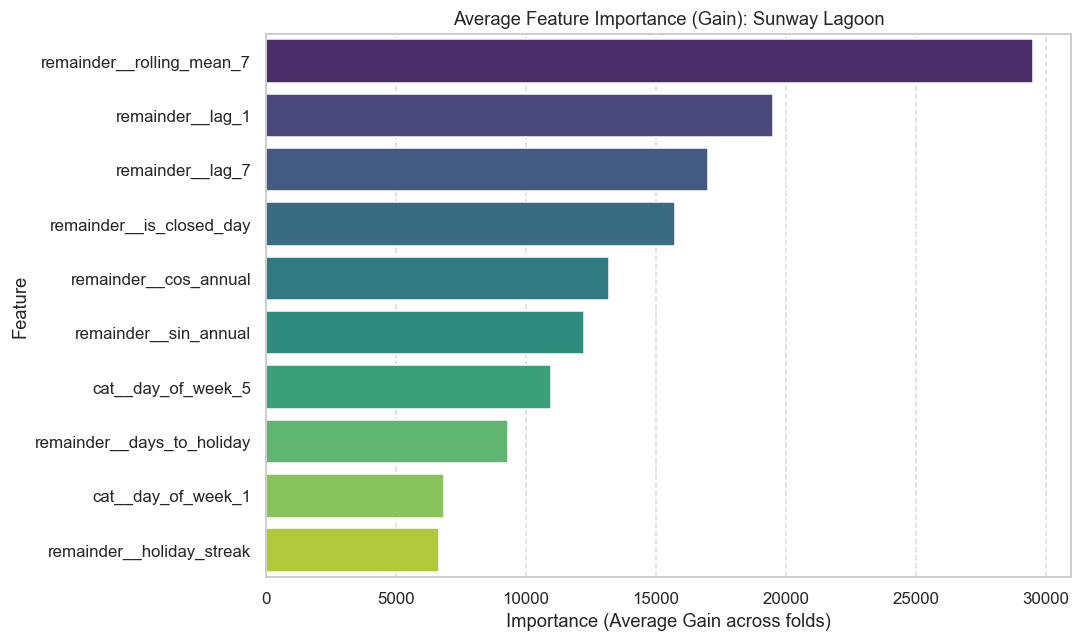

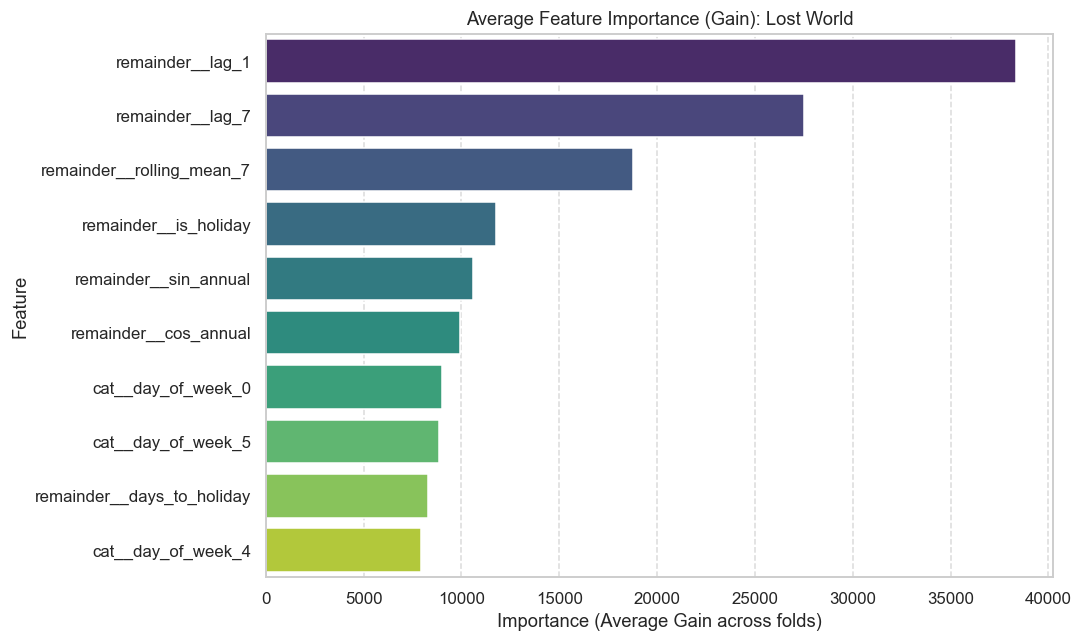

In [201]:
def plot_park_importance(final_importances, park_name, top_n=10):
    # 1. Filter dictionary keys for the specific park
    park_keys = [k for k in final_importances.keys() if k.startswith(park_name)]
    
    if not park_keys:
        print(f"No importance data found for {park_name}")
        return

    # 2. Combine all folds for this park and calculate the average
    all_imps = pd.concat([final_importances[k] for k in park_keys])
    avg_imp = all_imps.groupby('Feature')['Importance'].mean().sort_values(ascending=False).reset_index()

    # 3. Create the plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=avg_imp.head(top_n), x='Importance', y='Feature', palette='viridis')
    
    plt.title(f'Average Feature Importance (Gain): {park_name}')
    plt.xlabel('Importance (Average Gain across folds)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example Usage:
plot_park_importance(final_importances, 'Sunway Lagoon')
plot_park_importance(final_importances, 'Lost World')

Still no much improvement in average wmape even including the strategic event and strategic discount

### Weather Data Extraction

In [205]:
import requests
import pandas as pd
import time

def get_historical_weather(lat, lon, start_date, end_date):
    """Fetches daily precipitation and max temp from Open-Meteo."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ["precipitation_sum", "temperature_2m_max"],
        "timezone": "Asia/Singapore"
    }
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        weather_df = pd.DataFrame(data['daily'])
        weather_df['time'] = pd.to_datetime(weather_df['time'])
        return weather_df
    else:
        print(f"Error fetching weather: {response.status_code}")
        return pd.DataFrame()

# 1. Official Coordinates for your Analysis
# Sunway Lagoon: Subang Jaya, Selangor
# Lost World: Ipoh, Perak
park_locations = {
    'Sunway Lagoon': {'lat': 3.07199, 'lon': 101.60515},
    'Lost World': {'lat': 4.6258, 'lon': 101.1543}
}

# 2. Define Date Range
START_DATE = "2024-01-01"
END_DATE = "2025-12-31"

# 3. Execution Loop
weather_frames = []
print(f"Fetching Weather Data for {START_DATE} to {END_DATE}...")

for park, coords in park_locations.items():
    print(f" - Retrieving data for {park}...")
    w_df = get_historical_weather(coords['lat'], coords['lon'], START_DATE, END_DATE)
    w_df['park'] = park
    weather_frames.append(w_df)
    time.sleep(1) # Safety delay for API rate limits

# 4. Cleaning & Logic
full_weather_df = pd.concat(weather_frames)
full_weather_df.rename(columns={'time': 'visit_date', 'precipitation_sum': 'rain_mm'}, inplace=True)

Fetching Weather Data for 2024-01-01 to 2025-12-31...
 - Retrieving data for Sunway Lagoon...
 - Retrieving data for Lost World...


In [206]:
# Categorizing the severity of rain

# 1. Create a binned severity feature
# This allows the model to distinguish between 'Drizzle' and 'Monsoon'
def get_rain_severity(mm):
    if mm < 1.0: return 0    # None/Trace
    if mm <= 10.0: return 1  # Light
    if mm <= 30.0: return 2  # Moderate
    return 3                 # Heavy/Very Heavy

full_weather_df['rain_severity'] = full_weather_df['rain_mm'].apply(get_rain_severity)

In [207]:
full_weather_df.head(50)

,visit_date,rain_mm,temperature_2m_max,park,rain_severity
0,2024-01-01,7.5,30.0,Sunway Lagoon,1
1,2024-01-02,8.3,30.0,Sunway Lagoon,1
2,2024-01-03,22.8,29.9,Sunway Lagoon,2
3,2024-01-04,32.4,30.7,Sunway Lagoon,3
4,2024-01-05,1.3,30.9,Sunway Lagoon,1
5,2024-01-06,21.8,28.2,Sunway Lagoon,2
6,2024-01-07,13.7,26.8,Sunway Lagoon,2
7,2024-01-08,14.9,30.3,Sunway Lagoon,2
8,2024-01-09,35.0,28.5,Sunway Lagoon,3
9,2024-01-10,4.9,30.9,Sunway Lagoon,1


In [233]:
# Perform the inner merge
# We select only ['visit_date', 'park', 'rain_severity'] from full_weather_df
final_df = final_df.merge(
    full_weather_df[['visit_date', 'park', 'rain_severity', 'rain_mm']],
    on=['visit_date', 'park'],
    how='inner'
)

# Final Verification
print(f"Merge Complete. Final Shape: {final_df.shape}")
display(final_df.head())

Merge Complete. Final Shape: (1273, 32)


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday,day_of_month,is_payday_window,holiday_streak,lag_1,lag_7,rolling_mean_7,holiday_weekend,rolling_std_7,trend_velocity,dist_to_payday,is_strategic_discount,is_strategic_event,rain_severity,rain_mm
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0,1,1,1,0.0,0.0,0.0,1,NaN,NaN,24,1,0,1,2.3
1,2024-01-02,Lost World,457,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1,2,1,0,1505.0,0.0,0.0,0,NaN,NaN,23,1,0,1,1.5
2,2024-01-03,Lost World,1124,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2,3,1,0,457.0,0.0,0.0,0,NaN,NaN,22,1,0,1,8.9
3,2024-01-04,Lost World,1255,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3,4,0,0,1124.0,0.0,0.0,0,NaN,NaN,21,1,0,2,16.8
4,2024-01-05,Lost World,998,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4,5,0,0,1255.0,0.0,0.0,0,NaN,NaN,20,1,0,0,0.6


In [221]:
# Rerun the light GBM
# 1. Define final feature list based on your screenshot
# Note: Added 'is_day_session' back in as it's vital for this new grain
features_advanced = [
    'day_of_week', 'month_of_year',             # Categorical
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon',
    'days_to_holiday', 'is_payday_window', 'holiday_streak',
    'lag_1', 'lag_7', 'rolling_mean_7',
    'is_strategic_discount', 'is_strategic_event', 'rain_severity', 'rain_mm'
]

# Identify categorical features for the OneHotEncoder
cat_features_for_model = ['day_of_week', 'month_of_year','rain_severity']

# Merging change the variable name of response
target = 'visitors'

In [222]:
# 2. Storage
results = []
final_importances = {}
all_predictions_list = []

# 3. Setup Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_for_model)
    ],
    remainder='passthrough'
)

# 4. Training Loop
months = sorted(final_df["visit_date"].dt.to_period("M").unique())
parks = final_df['park'].unique()

print(f"Training Advanced Model on {len(parks)} parks across {len(months)-7} test months...")

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    # Slice time
    train_df_full = final_df[final_df["visit_date"] <= train_end]
    test_df_full = final_df[final_df["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p].copy()
        test_df = test_df_full[test_df_full['park'] == p].copy()
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define the Pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(
                n_estimators=2000,
                learning_rate=0.005,
                max_depth=6,
                objective='regression_l1',
                random_state=42,
                n_jobs=-1,
                importance_type='gain',
                verbosity=-1
            ))
        ])
        
        # Fit & Predict
        # We avoid Early Stopping here to prevent data leakage from the test month
        model.fit(train_df[features_advanced], train_df[target])
        
        
        # Capture Importances for this park
        fitted_preprocessor = model.named_steps['preprocessor']
        feature_names = fitted_preprocessor.get_feature_names_out(features_advanced)
        importances = model.named_steps['regressor'].feature_importances_
        
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict & Clip
        pred = np.clip(model.predict(test_df[features_advanced]), 0, None)

        # Store results for WMAPE calculation
        p_df = test_df[['park', 'visit_date', target]].copy()
        p_df['prediction'] = pred
        all_predictions_list.append(p_df)
        
        # Evaluate using your get_metrics function
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        results.append(metrics)

# 5. Summary
results_df = pd.DataFrame(results)
summary = results_df.groupby(["park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Advanced Model Performance (Session Level) ===")
print(summary)

Training Advanced Model on 2 parks across 15 test months...

=== Advanced Model Performance (Session Level) ===
               avg_wmape  std_wmape   avg_mae  avg_bias  n_folds
park                                                            
Lost World        0.2576     0.0901  487.3034   -0.8745       15
Sunway Lagoon     0.3071     0.1007  832.9626  -93.6798       15


In [223]:
final_importances

{'Lost World':                              Feature    Importance
 33                  remainder__lag_1  39082.875273
 34                  remainder__lag_7  28598.745030
 35         remainder__rolling_mean_7  17962.659656
 23             remainder__is_holiday  11232.272935
 27             remainder__sin_annual  10272.644673
 38                remainder__rain_mm  10221.503312
 28             remainder__cos_annual  10205.280934
 5                 cat__day_of_week_5   8851.780486
 0                 cat__day_of_week_0   8850.794716
 30        remainder__days_to_holiday   8575.940760
 4                 cat__day_of_week_4   7806.752281
 32         remainder__holiday_streak   4332.925610
 24          remainder__is_closed_day   3994.303967
 1                 cat__day_of_week_1   3784.269548
 31       remainder__is_payday_window   2507.799284
 26             remainder__is_ramadan   1734.638970
 20              cat__rain_severity_1    625.823404
 6                 cat__day_of_week_6    604.17933

In [224]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   visit_date             1273 non-null   datetime64[us]
 1   park                   1273 non-null   str           
 2   visitors               1273 non-null   int64         
 3   calendar_date          1268 non-null   str           
 4   holiday_name           332 non-null    str           
 5   is_school_holiday      1273 non-null   int64         
 6   is_public_holiday      1273 non-null   int64         
 7   is_holiday             1273 non-null   int64         
 8   is_closed_day          1273 non-null   int64         
 9   is_long_weekend        1273 non-null   int64         
 10  is_ramadan             1273 non-null   int64         
 11  month_of_year          1273 non-null   int64         
 12  day_of_week            1273 non-null   int64         
 13  day_of_year   

In [ ]:
final_df = final_df.drop(columns=['rolling_std_7','trend_velocity','dist_to_payday'])

In [226]:
final_df.head(10)

,visit_date,park,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,has_nof_lagoon,days_to_holiday,day_of_month,is_payday_window,holiday_streak,lag_1,lag_7,rolling_mean_7,holiday_weekend,is_strategic_discount,is_strategic_event,rain_severity,rain_mm
0,2024-01-01,Lost World,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,0,0,1,1,1,0.0,0.0,0.000000,1,1,0,1,2.3
1,2024-01-02,Lost World,2024-01-02,NaN,0,0,0,1,0,0,1,1,2,0.034398,0.999408,0,-1,2,1,0,1505.0,0.0,0.000000,0,1,0,1,1.5
2,2024-01-03,Lost World,2024-01-03,NaN,0,0,0,0,0,0,1,2,3,0.051584,0.998669,0,-2,3,1,0,457.0,0.0,0.000000,0,1,0,1,8.9
3,2024-01-04,Lost World,2024-01-04,NaN,0,0,0,0,0,0,1,3,4,0.068755,0.997634,0,-3,4,0,0,1124.0,0.0,0.000000,0,1,0,2,16.8
4,2024-01-05,Lost World,2024-01-05,NaN,0,0,0,0,0,0,1,4,5,0.085906,0.996303,0,-4,5,0,0,1255.0,0.0,0.000000,0,1,0,0,0.6
5,2024-01-06,Lost World,2024-01-06,NaN,0,0,0,0,0,0,1,5,6,0.103031,0.994678,0,-5,6,0,0,998.0,0.0,0.000000,0,1,0,2,29.2
6,2024-01-07,Lost World,2024-01-07,NaN,0,0,0,0,0,0,1,6,7,0.120126,0.992759,0,-6,7,0,0,2549.0,0.0,1286.142857,0,1,0,2,13.9
7,2024-01-08,Lost World,2024-01-08,NaN,0,0,0,0,0,0,1,0,8,0.137185,0.990545,0,-7,8,0,0,1115.0,1505.0,1162.714286,0,1,0,1,8.8
8,2024-01-09,Lost World,2024-01-09,NaN,0,0,0,1,0,0,1,1,9,0.154204,0.988039,0,-8,9,0,0,641.0,457.0,1136.142857,0,1,0,2,14.6
9,2024-01-10,Lost World,2024-01-10,NaN,0,0,0,0,0,0,1,2,10,0.171177,0.985240,0,-9,10,0,0,271.0,1124.0,1138.000000,0,1,0,1,3.7


### Further Feature Engineering

In [234]:
# 1. Create the binary 'is_raining' proxy from severity
# This maps 0 to 0, and any number (1, 2, 3) to 1
final_df['is_raining_any'] = (final_df['rain_severity'] > 0).astype(int)

# 2. Update the Rain and Weekend Interaction
# 1 if it's a weekend AND there is any rain, 0 otherwise
final_df['is_weekend'] = final_df['day_of_week'].isin([5, 6]).astype(int)
final_df['rain_weekend_interaction'] = final_df['is_raining_any'] * final_df['is_weekend']

# 2. Holiday and Rain Severity Interaction
# Multiplies binary holiday flag by 0-3 severity scale
final_df['holiday_rain_impact'] = final_df['is_holiday'] * final_df['rain_severity'] #categorical

# 3. Strategic Event and Recent Trend Interaction
# Captures how much an event 'boosts' the existing 7-day average
final_df['event_trend_boost'] = final_df['is_strategic_event'] * final_df['rolling_mean_7']

In [238]:
# Update the feature list

# 1. Define final feature list based on your screenshot
# Note: Added 'is_day_session' back in as it's vital for this new grain
features_advanced = [
    'day_of_week', 'month_of_year',             # Categorical
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon',
    'days_to_holiday', 'is_payday_window', 'holiday_streak',
    'lag_1', 'lag_7', 'rolling_mean_7',
    'is_strategic_discount', 'is_strategic_event', 'rain_severity', 'rain_mm',
    'rain_weekend_interaction', 'holiday_rain_impact', 'event_trend_boost'
]

# Identify categorical features for the OneHotEncoder
cat_features_for_model = ['day_of_week', 'month_of_year','rain_severity', 'holiday_rain_impact']

# Merging change the variable name of response
target = 'visitors'

In [242]:
features_advanced

['day_of_week',
 'month_of_year',
 'is_holiday',
 'is_closed_day',
 'is_long_weekend',
 'is_ramadan',
 'sin_annual',
 'cos_annual',
 'has_nof_lagoon',
 'days_to_holiday',
 'is_payday_window',
 'holiday_streak',
 'lag_1',
 'lag_7',
 'rolling_mean_7',
 'is_strategic_discount',
 'is_strategic_event',
 'rain_severity',
 'rain_mm',
 'rain_weekend_interaction',
 'holiday_rain_impact',
 'event_trend_boost']

In [240]:
# 2. Storage
results = []
final_importances = {}
all_predictions_list = []

# 3. Setup Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_for_model)
    ],
    remainder='passthrough'
)

# 4. Training Loop
months = sorted(final_df["visit_date"].dt.to_period("M").unique())
parks = final_df['park'].unique()

print(f"Training Advanced Model on {len(parks)} parks across {len(months)-7} test months...")

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    # Slice time
    train_df_full = final_df[final_df["visit_date"] <= train_end]
    test_df_full = final_df[final_df["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p].copy()
        test_df = test_df_full[test_df_full['park'] == p].copy()
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define the Pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(
                n_estimators=2000,
                learning_rate=0.005,
                max_depth=6,
                objective='regression_l1',
                random_state=42,
                n_jobs=-1,
                importance_type='gain',
                verbosity=-1
            ))
        ])
        
        # Fit & Predict
        # We avoid Early Stopping here to prevent data leakage from the test month
        model.fit(train_df[features_advanced], train_df[target])
        
        
        # Capture Importances for this park
        fitted_preprocessor = model.named_steps['preprocessor']
        feature_names = fitted_preprocessor.get_feature_names_out(features_advanced)
        importances = model.named_steps['regressor'].feature_importances_
        
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict & Clip
        pred = np.clip(model.predict(test_df[features_advanced]), 0, None)

        # Store results for WMAPE calculation
        p_df = test_df[['park', 'visit_date', target]].copy()
        p_df['prediction'] = pred
        all_predictions_list.append(p_df)
        
        # Evaluate using your get_metrics function
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        results.append(metrics)

# 5. Summary
results_df = pd.DataFrame(results)
summary = results_df.groupby(["park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Advanced Model Performance (Session Level) ===")
print(summary)

Training Advanced Model on 2 parks across 15 test months...

=== Advanced Model Performance (Session Level) ===
               avg_wmape  std_wmape   avg_mae  avg_bias  n_folds
park                                                            
Lost World        0.2559     0.0868  484.1585   -8.0316       15
Sunway Lagoon     0.3068     0.1018  828.5282 -101.6620       15


In [241]:
final_importances

{'Lost World':                                 Feature    Importance
 37                     remainder__lag_1  38090.939203
 38                     remainder__lag_7  27800.033839
 39            remainder__rolling_mean_7  17691.002203
 27                remainder__is_holiday  11597.846317
 31                remainder__sin_annual  10261.455467
 42                   remainder__rain_mm   9639.449950
 5                    cat__day_of_week_5   9278.549903
 32                remainder__cos_annual   9180.459379
 0                    cat__day_of_week_0   8907.938774
 34           remainder__days_to_holiday   8419.948056
 4                    cat__day_of_week_4   7890.036145
 36            remainder__holiday_streak   4601.045411
 1                    cat__day_of_week_1   4350.962983
 28             remainder__is_closed_day   3212.902638
 35          remainder__is_payday_window   2706.193066
 30                remainder__is_ramadan   1480.230184
 20                 cat__rain_severity_1    732.856

### Switching to log the visitors
+ Change it to mape instead of l1 penalty, still no significant improvement
For adjustment of sudden spike

In [244]:
# 2. Storage
results = []
final_importances = {}
all_predictions_list = []

# 3. Setup Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_for_model)
    ],
    remainder='passthrough'
)

# 4. Training Loop
months = sorted(final_df["visit_date"].dt.to_period("M").unique())
parks = final_df['park'].unique()

print(f"Training Advanced Model on {len(parks)} parks across {len(months)-7} test months...")

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    # Slice time
    train_df_full = final_df[final_df["visit_date"] <= train_end]
    test_df_full = final_df[final_df["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p].copy()
        test_df = test_df_full[test_df_full['park'] == p].copy()
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define the Pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(
                n_estimators=2000,
                learning_rate=0.005,
                max_depth=6,
                objective='mape', #<-- Directly targets percentage error but not l1 penalty
                random_state=42,
                n_jobs=-1,
                importance_type='gain',
                verbosity=-1
            ))
        ])
        
        # Fit & Predict
        # We avoid Early Stopping here to prevent data leakage from the test month
        model.fit(train_df[features_advanced], np.log1p(train_df[target]))
        
        
        # Capture Importances for this park
        fitted_preprocessor = model.named_steps['preprocessor']
        feature_names = fitted_preprocessor.get_feature_names_out(features_advanced)
        importances = model.named_steps['regressor'].feature_importances_
        
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict & Clip
        # Convert back from log <-- Changes made here
        log_pred = model.predict(test_df[features_advanced])
        pred = np.expm1(log_pred)
        pred = np.clip(pred, 0, None)

        # Store results for WMAPE calculation
        p_df = test_df[['park', 'visit_date', target]].copy()
        p_df['prediction'] = pred
        all_predictions_list.append(p_df)
        
        # Evaluate using your get_metrics function
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        results.append(metrics)

# 5. Summary
results_df = pd.DataFrame(results)
summary = results_df.groupby(["park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Advanced Model Performance (Session Level) ===")
print(summary)

Training Advanced Model on 2 parks across 15 test months...

=== Advanced Model Performance (Session Level) ===
               avg_wmape  std_wmape   avg_mae  avg_bias  n_folds
park                                                            
Lost World        0.2530     0.0849  478.5711  -53.6947       15
Sunway Lagoon     0.3075     0.1013  831.9896 -208.2913       15


### Incorporating holiday magnitude

In [245]:
# Calculate the historical average visitors per holiday name
# Use a transform to broadcast this back to the original dataframe
final_df['holiday_magnitude'] = final_df.groupby('holiday_name')['visitors'].transform('mean')

# Fill non-holidays with 0 or the global median
final_df['holiday_magnitude'] = final_df['holiday_magnitude'].fillna(0)

# Add this to your feature list
features_advanced.append('holiday_magnitude')

In [249]:
final_df['holiday_name'].unique()

<ArrowStringArray>
[               'New Year Day',                           nan,                   'Thaipusam',            'Chinese New Year',              'School Holiday',              'Nurul Al-Quran',        'Hari Raya Aidilfitri',
                  'Labour Day',                   'Wesak Day',              'Agong Birthday',              'Hari Raya Haji',               'Awal Muharram',                'National Day', 'Prophet Muhammad's Birthday',
                   'Deepavali',       'Sultan Perak Birthday']
Length: 16, dtype: str

In [250]:
# 2. Storage
results = []
final_importances = {}
all_predictions_list = []

# 3. Setup Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_for_model)
    ],
    remainder='passthrough'
)

# 4. Training Loop
months = sorted(final_df["visit_date"].dt.to_period("M").unique())
parks = final_df['park'].unique()

print(f"Training Advanced Model on {len(parks)} parks across {len(months)-7} test months...")

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    # Slice time
    train_df_full = final_df[final_df["visit_date"] <= train_end]
    test_df_full = final_df[final_df["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p].copy()
        test_df = test_df_full[test_df_full['park'] == p].copy()
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define the Pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(
                n_estimators=2000,
                learning_rate=0.005,
                max_depth=6,
                objective='poisson', #<-- Directly targets percentage error but not l1 penalty, customer data is discrete
                random_state=42,
                n_jobs=-1,
                importance_type='gain',
                verbosity=-1
            ))
        ])
        
        # Fit & Predict
        # We avoid Early Stopping here to prevent data leakage from the test month
        model.fit(train_df[features_advanced], np.log1p(train_df[target]))
        
        
        # Capture Importances for this park
        fitted_preprocessor = model.named_steps['preprocessor']
        feature_names = fitted_preprocessor.get_feature_names_out(features_advanced)
        importances = model.named_steps['regressor'].feature_importances_
        
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict & Clip
        # Convert back from log <-- Changes made here
        log_pred = model.predict(test_df[features_advanced])
        pred = np.expm1(log_pred)
        pred = np.clip(pred, 0, None)

        # Store results for WMAPE calculation
        p_df = test_df[['park', 'visit_date', target]].copy()
        p_df['prediction'] = pred
        all_predictions_list.append(p_df)
        
        # Evaluate using your get_metrics function
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        results.append(metrics)

# 5. Summary
results_df = pd.DataFrame(results)
summary = results_df.groupby(["park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Advanced Model Performance (Session Level) ===")
print(summary)

Training Advanced Model on 2 parks across 15 test months...

=== Advanced Model Performance (Session Level) ===
               avg_wmape  std_wmape   avg_mae  avg_bias  n_folds
park                                                            
Lost World        0.2584     0.0776  488.4502  -49.9478       15
Sunway Lagoon     0.3087     0.0988  833.3531 -240.3110       15


In [267]:
# 1. Engineering Magnitudes & Proximity
# We create separate magnitudes for School vs Public holidays to avoid 'averaging' the impact
final_df['school_mag'] = final_df.loc[final_df['is_school_holiday']==1].groupby('holiday_name')['visitors'].transform('mean')
final_df['public_mag'] = final_df.loc[final_df['is_public_holiday']==1].groupby('holiday_name')['visitors'].transform('mean')

# Fill NaNs and create a countdown to the next holiday
final_df[['school_mag', 'public_mag']] = final_df[['school_mag', 'public_mag']].fillna(0)

In [268]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   visit_date                1273 non-null   datetime64[us]
 1   park                      1273 non-null   str           
 2   visitors                  1273 non-null   int64         
 3   calendar_date             1268 non-null   str           
 4   holiday_name              332 non-null    str           
 5   is_school_holiday         1273 non-null   int64         
 6   is_public_holiday         1273 non-null   int64         
 7   is_holiday                1273 non-null   int64         
 8   is_closed_day             1273 non-null   int64         
 9   is_long_weekend           1273 non-null   int64         
 10  is_ramadan                1273 non-null   int64         
 11  month_of_year             1273 non-null   int64         
 12  day_of_week               1273 

In [269]:
features_advanced = [
    'day_of_week', 'month_of_year',             # Categorical
    'is_holiday', 'is_closed_day', 'is_long_weekend', 
    'is_ramadan', 'sin_annual', 'cos_annual', 'has_nof_lagoon',
    'days_to_holiday', 'is_payday_window', 'holiday_streak',
    'lag_1', 'lag_7', 'rolling_mean_7',
    'is_strategic_discount', 'is_strategic_event', 'rain_severity', 'rain_mm',
    'rain_weekend_interaction', 'holiday_rain_impact', 'event_trend_boost',
    'holiday_magnitude',
    'school_mag', 'public_mag'
]

target = 'visitors'

In [270]:
features_advanced

['day_of_week',
 'month_of_year',
 'is_holiday',
 'is_closed_day',
 'is_long_weekend',
 'is_ramadan',
 'sin_annual',
 'cos_annual',
 'has_nof_lagoon',
 'days_to_holiday',
 'is_payday_window',
 'holiday_streak',
 'lag_1',
 'lag_7',
 'rolling_mean_7',
 'is_strategic_discount',
 'is_strategic_event',
 'rain_severity',
 'rain_mm',
 'rain_weekend_interaction',
 'holiday_rain_impact',
 'event_trend_boost',
 'holiday_magnitude',
 'school_mag',
 'public_mag']

In [271]:
# 2. Storage
results = []
final_importances = {}
all_predictions_list = []

# 3. Setup Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_for_model)
    ],
    remainder='passthrough'
)

# 4. Training Loop
months = sorted(final_df["visit_date"].dt.to_period("M").unique())
parks = final_df['park'].unique()

print(f"Training Advanced Model on {len(parks)} parks across {len(months)-7} test months...")

for i in range(6, len(months) - 1):
    train_end = months[i].to_timestamp(how='end')
    # Slice time
    train_df_full = final_df[final_df["visit_date"] <= train_end]
    test_df_full = final_df[final_df["visit_date"].dt.to_period("M") == months[i+1]]
    
    for p in parks:
        train_df = train_df_full[train_df_full['park'] == p].copy()
        test_df = test_df_full[test_df_full['park'] == p].copy()
        
        if len(train_df) == 0 or len(test_df) == 0:
            continue
            
        # Define the Pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(
                n_estimators=2000,
                learning_rate=0.005,
                max_depth=6,
                objective='poisson', #<-- Directly targets percentage error but not l1 penalty, customer data is discrete
                random_state=42,
                n_jobs=-1,
                importance_type='gain',
                verbosity=-1
            ))
        ])
        
        # Fit & Predict
        # We avoid Early Stopping here to prevent data leakage from the test month
        model.fit(train_df[features_advanced], np.log1p(train_df[target]))
        
        
        # Capture Importances for this park
        fitted_preprocessor = model.named_steps['preprocessor']
        feature_names = fitted_preprocessor.get_feature_names_out(features_advanced)
        importances = model.named_steps['regressor'].feature_importances_
        
        final_importances[p] = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        
        # Predict & Clip
        # Convert back from log <-- Changes made here
        log_pred = model.predict(test_df[features_advanced])
        pred = np.expm1(log_pred)
        pred = np.clip(pred, 0, None)

        # Store results for WMAPE calculation
        p_df = test_df[['park', 'visit_date', target]].copy()
        p_df['prediction'] = pred
        all_predictions_list.append(p_df)
        
        # Evaluate using your get_metrics function
        metrics = get_metrics(test_df[target], pred, None)
        metrics["park"] = p
        results.append(metrics)

# 5. Summary
results_df = pd.DataFrame(results)
summary = results_df.groupby(["park"]).agg(
    avg_wmape=("wmape", "mean"),
    std_wmape=("wmape", "std"),
    avg_mae=("mae", "mean"),
    avg_bias=("bias", "mean"),
    n_folds=("wmape", "count")
).round(4)

print("\n=== Advanced Model Performance (Session Level) ===")
print(summary)

Training Advanced Model on 2 parks across 15 test months...

=== Advanced Model Performance (Session Level) ===
               avg_wmape  std_wmape   avg_mae  avg_bias  n_folds
park                                                            
Lost World        0.2597     0.0809  490.6836  -50.6485       15
Sunway Lagoon     0.3071     0.1029  827.6165 -238.2454       15
